In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original dataset
df = pd.read_csv("/content/drive/MyDrive/VDSWP/week-6/Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")

print("\nShape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all").T)

Dataset loaded successfully!

Shape:
(7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Churn distribution:")
display(df["Churn"].value_counts())

print("\nChurn percentage:")
display(df["Churn"].value_counts(normalize=True) * 100)

Churn distribution:


,count
Churn,
No,5174
Yes,1869



Churn percentage:


,proportion
Churn,
No,73.463013
Yes,26.536987


In [6]:
# Create a separate cleaned copy
clean_df = df.copy()

# Remove leading/trailing whitespace from text columns
text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].astype(str).str.strip()

# Convert TotalCharges from text to numeric
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

# Check how many values became missing after conversion
print("Missing TotalCharges after numeric conversion:",
      clean_df["TotalCharges"].isna().sum())

# Fill missing TotalCharges with 0
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0.0)

print("\nData types after cleaning:")
print(clean_df.dtypes)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(clean_df.duplicated().sum())

Missing TotalCharges after numeric conversion: 11

Data types after cleaning:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
St

In [7]:
print("Cleaned dataset shape:", clean_df.shape)

print("\nTotalCharges sample:")
display(clean_df[["tenure", "MonthlyCharges", "TotalCharges"]].head(10))

print("\nTotalCharges statistics:")
display(clean_df["TotalCharges"].describe())

Cleaned dataset shape: (7043, 21)

TotalCharges sample:


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.50
6,22,89.10,1949.40
7,10,29.75,301.90
8,28,104.80,3046.05
9,62,56.15,3487.95



TotalCharges statistics:


,TotalCharges
count,7043.000000
mean,2279.734304
std,2266.794470
min,0.000000
25%,398.550000
50%,1394.550000
75%,3786.600000
max,8684.800000


In [8]:
# ============================================================
# FINAL DATA VALIDATION
# ============================================================

# 1. Verify the originally blank TotalCharges records
original_blank = df["TotalCharges"].astype(str).str.strip().eq("")

print("1. Originally blank TotalCharges records:")
display(
    df.loc[
        original_blank,
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

print("Number of originally blank records:", original_blank.sum())

print("\nTenure values of these records:")
print(df.loc[original_blank, "tenure"].value_counts())


# 2. Check unique categorical values
categorical_columns = clean_df.select_dtypes(include="object").columns

print("\n2. Unique categorical values:")
for col in categorical_columns:
    print(f"\n{col}:")
    print(clean_df[col].unique())


# 3. Check numerical ranges
print("\n3. Numerical ranges:")

numeric_columns = clean_df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    print(
        f"{col}: "
        f"min={clean_df[col].min()}, "
        f"max={clean_df[col].max()}"
    )


# 4. Final quality checks
print("\n4. Final quality checks:")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())
print("TotalCharges dtype:", clean_df["TotalCharges"].dtype)

print("\nData validation completed.")

1. Originally blank TotalCharges records:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Number of originally blank records: 11

Tenure values of these records:
tenure
0    11
Name: count, dtype: int64

2. Unique categorical values:

customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']

3. Numerical ranges:
SeniorCitizen: min=0

In [9]:
# Save cleaned dataset to Google Drive
cleaned_file = "/content/drive/MyDrive/VDSWP/week-6/Telco-Customer-Churn-Cleaned.csv"

clean_df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully!")
print("File path:", cleaned_file)
print("Shape:", clean_df.shape)

# Final confirmation
print("\nFinal checks:")
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())
print("TotalCharges dtype:", clean_df["TotalCharges"].dtype)

Cleaned dataset saved successfully!
File path: /content/drive/MyDrive/VDSWP/week-6/Telco-Customer-Churn-Cleaned.csv
Shape: (7043, 21)

Final checks:
Missing values: 0
Duplicate rows: 0
TotalCharges dtype: float64


WEEK 6 - EXPLORATORY DATA ANALYSIS

Dataset shape: (7043, 21)

1. OVERALL CHURN DISTRIBUTION

Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Overall churn rate: 26.54%


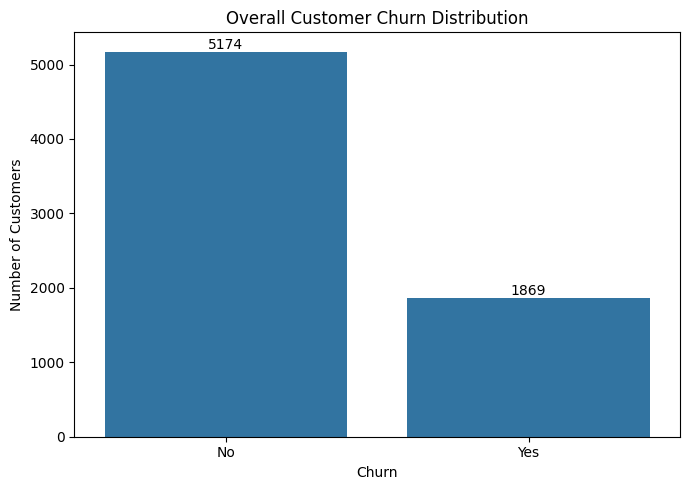


2. NUMERICAL VARIABLE SUMMARY


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80



3. NUMERICAL VARIABLES BY CHURN


tenure                              MonthlyCharges                       \
       count   mean median    std min max          count   mean median    std   
Churn                                                                           
No      5174  37.57   38.0  24.11   0  72           5174  61.27  64.43  31.09   
Yes     1869  17.98   10.0  19.53   1  72           1869  74.44  79.65  24.67   

                     TotalCharges                                             
         min     max        count     mean   median      std    min      max  
Churn                                                                         
No     18.25  118.75         5174  2549.91  1679.52  2329.95   0.00  8672.45  
Yes    18.85  118.35         1869  1531.80   703.55  1890.82  18.85  8684.80

,Mean_No_Churn,Mean_Yes_Churn,Difference_Yes_minus_No
tenure,37.57,17.98,-19.59
MonthlyCharges,61.27,74.44,13.18
TotalCharges,2549.91,1531.80,-1018.12


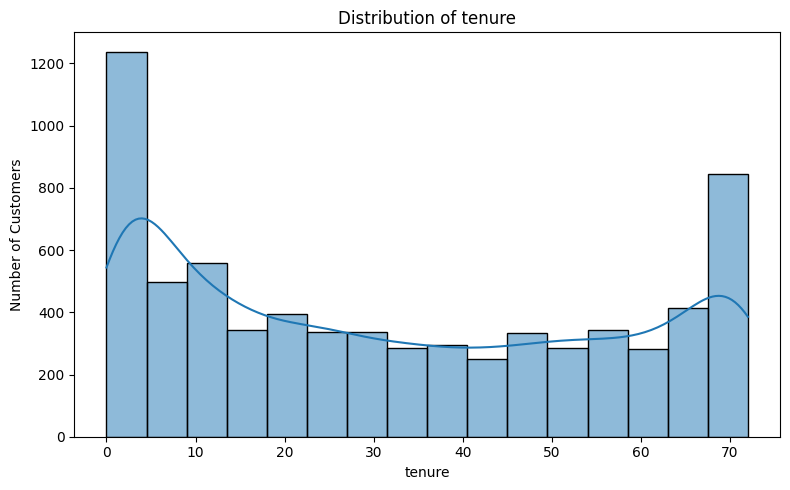

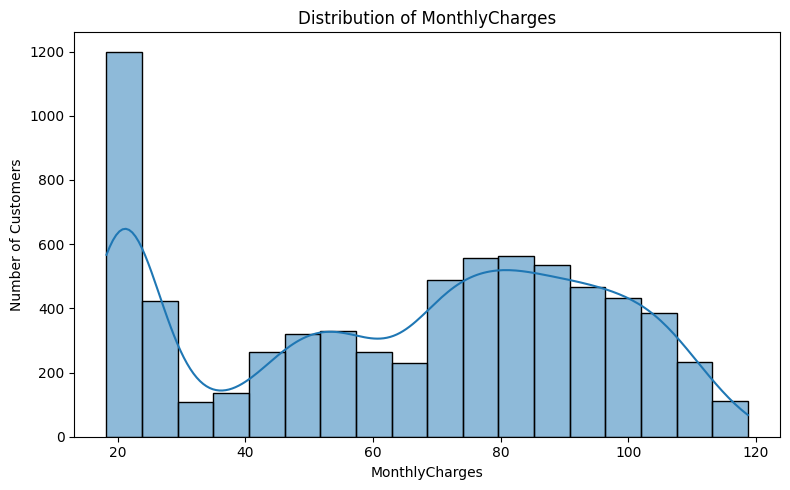

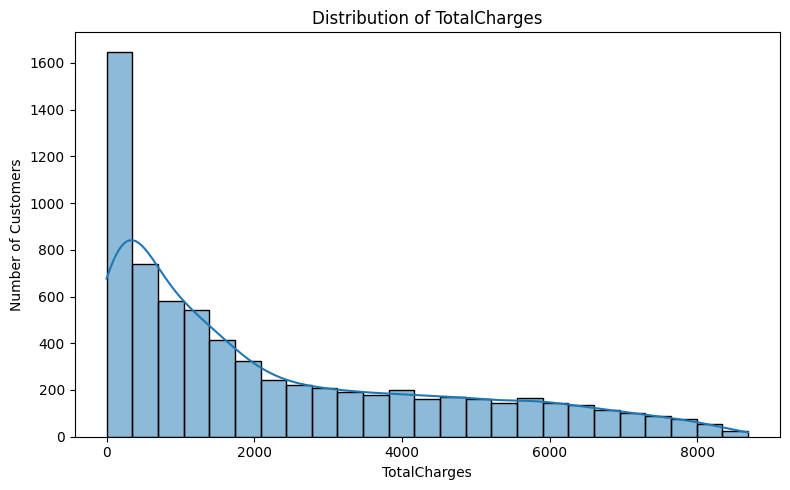


4. CHURN RATE BY CATEGORICAL VARIABLES

--- gender ---


,gender,count,sum,Churn_Rate_Percent,Overall_Churn_Difference
0,Female,3488,939,26.92,0.38
1,Male,3555,930,26.16,-0.38



--- SeniorCitizen ---


,SeniorCitizen,count,sum,Churn_Rate_Percent,Overall_Churn_Difference
0,0,5901,1393,23.61,-2.93
1,1,1142,476,41.68,15.14



--- Partner ---


...

,Contract,count,sum,Churn_Rate_Percent,Overall_Churn_Difference
0,Month-to-month,3875,1655,42.71,16.17
1,One year,1473,166,11.27,-15.27
2,Two year,1695,48,2.83,-23.71



--- PaperlessBilling ---


,PaperlessBilling,count,sum,Churn_Rate_Percent,Overall_Churn_Difference
0,No,2872,469,16.33,-10.21
1,Yes,4171,1400,33.57,7.03



--- PaymentMethod ---


,PaymentMethod,count,sum,Churn_Rate_Percent,Overall_Churn_Difference
0,Bank transfer (automatic),1544,258,16.71,-9.83
1,Credit card (automatic),1522,232,15.24,-11.29
2,Electronic check,2365,1071,45.29,18.75
3,Mailed check,1612,308,19.11,-7.43


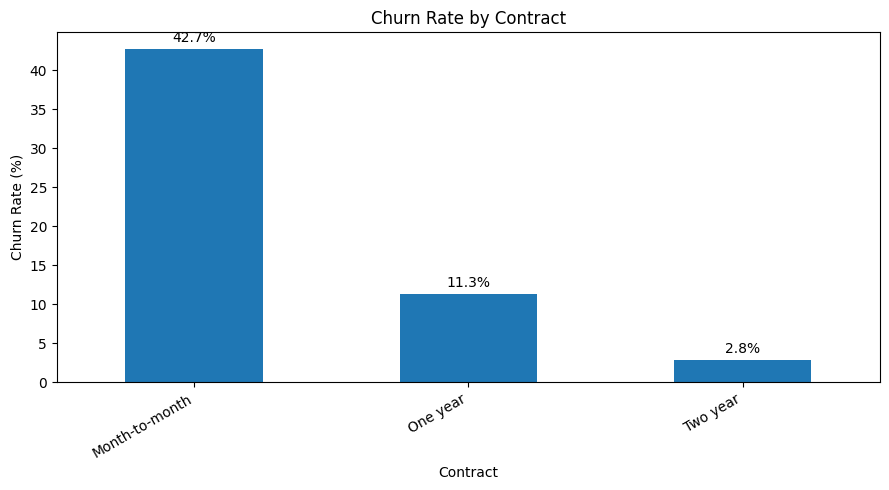

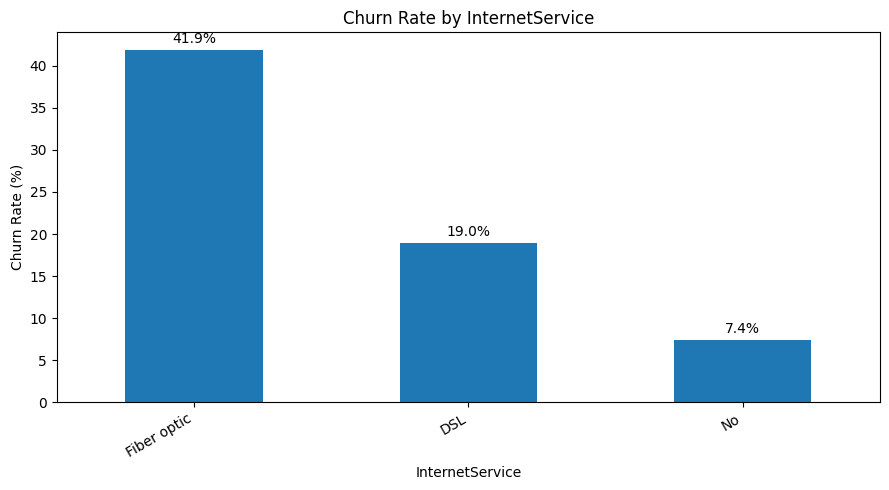

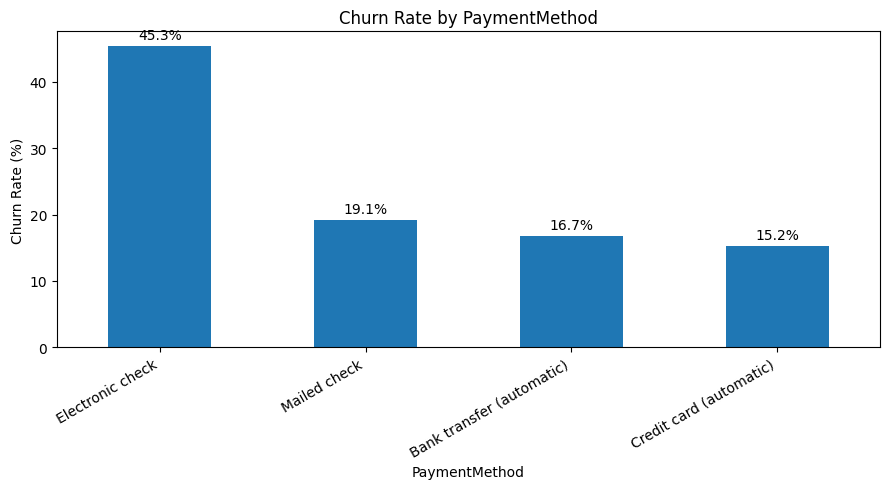

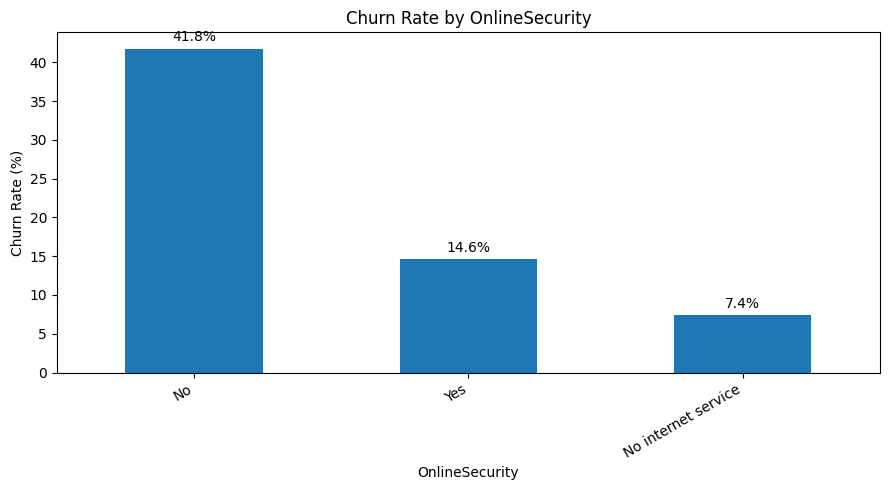

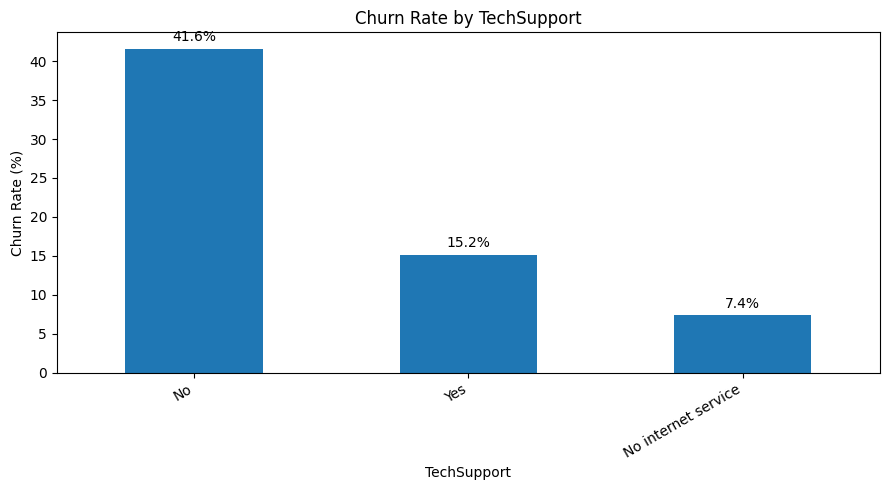

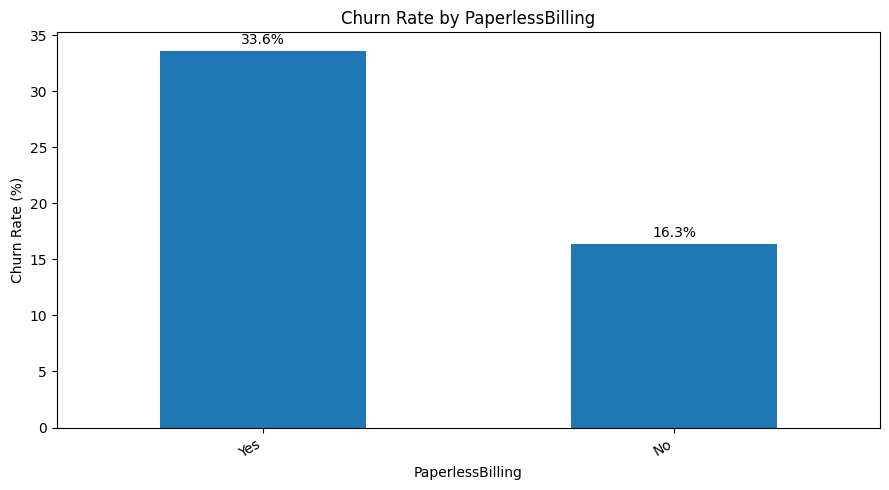


5. CHURN BY TENURE GROUP


,Tenure_Group,count,sum,mean,Churn_Rate_Percent
0,0-6 months,1481,784,0.53,52.94
1,7-12 months,705,253,0.36,35.89
2,13-24 months,1024,294,0.29,28.71
3,25-48 months,1594,325,0.20,20.39
4,49-72 months,2239,213,0.10,9.51


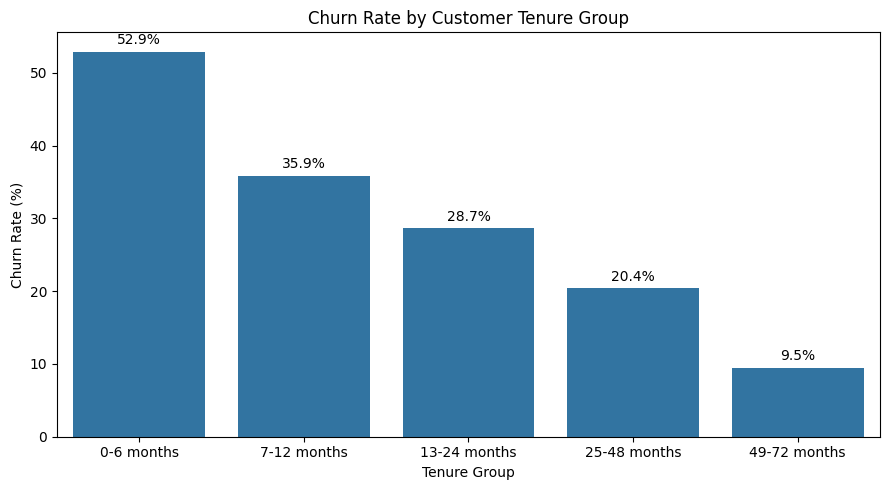

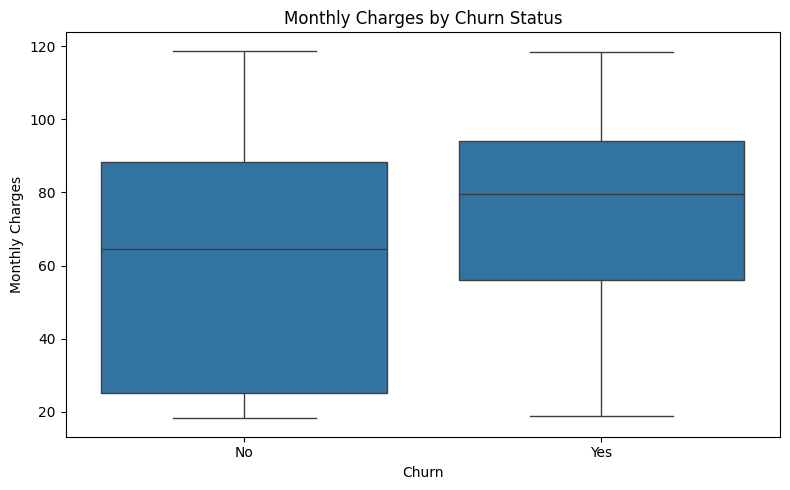

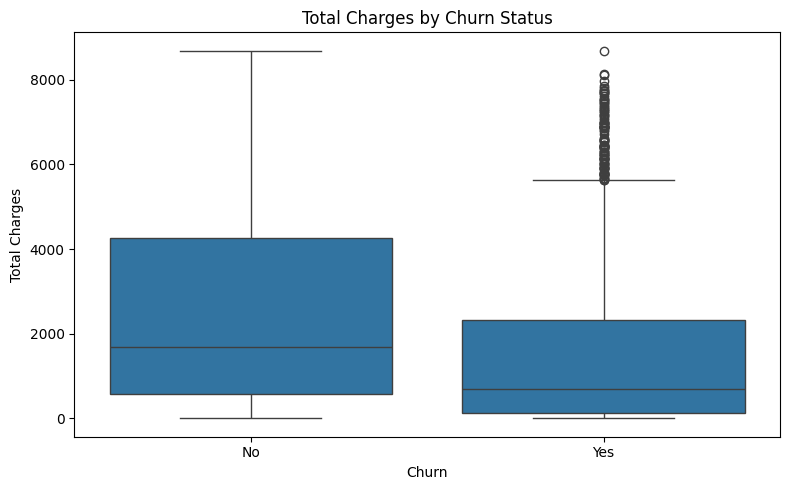


6. NUMBER OF SERVICES VS CHURN


,Num_Services,count,sum,mean,Churn_Rate_Percent
0,0,80,35,0.44,43.75
1,1,1701,359,0.21,21.11
2,2,1188,390,0.33,32.83
3,3,965,352,0.36,36.48
4,4,922,289,0.31,31.34
5,5,908,232,0.26,25.55
6,6,676,152,0.22,22.49
7,7,395,49,0.12,12.41
8,8,208,11,0.05,5.29


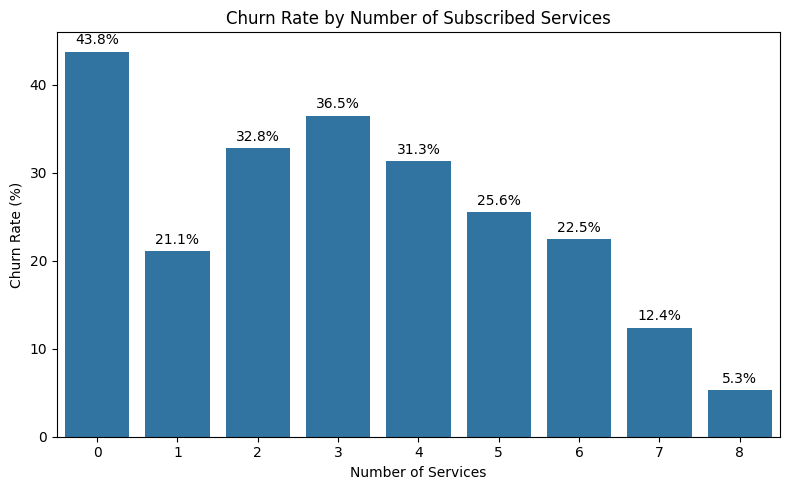


7. NUMERICAL CORRELATION WITH CHURN


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Num_Services,Churn_Binary
SeniorCitizen,1.000,0.017,0.220,0.103,0.096,0.151
tenure,0.017,1.000,0.248,0.826,0.524,-0.352
MonthlyCharges,0.220,0.248,1.000,0.651,0.802,0.193
TotalCharges,0.103,0.826,0.651,1.000,0.796,-0.198
Num_Services,0.096,0.524,0.802,0.796,1.000,-0.067
Churn_Binary,0.151,-0.352,0.193,-0.198,-0.067,1.000


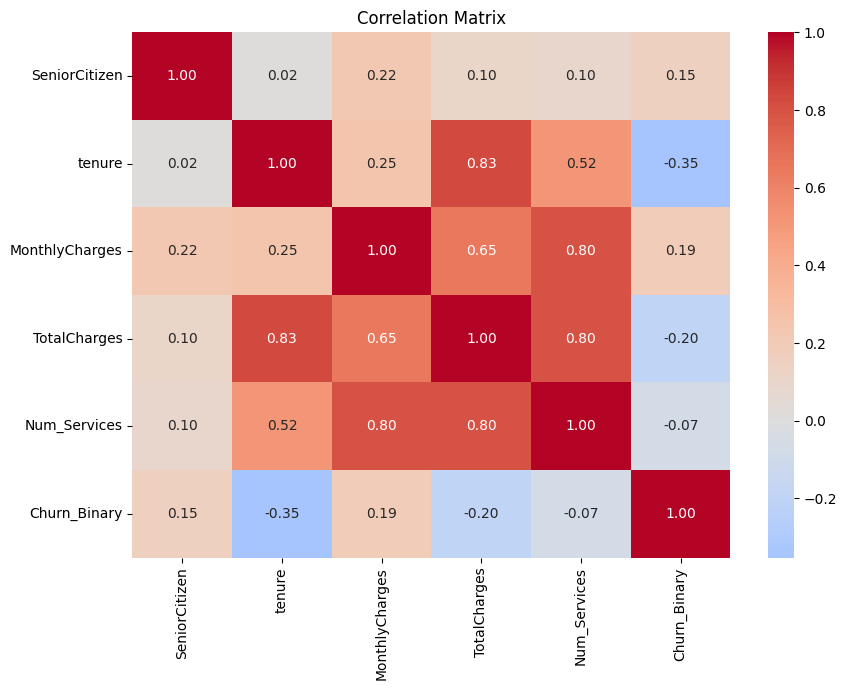


8. CHURN BY SENIOR CITIZEN STATUS


,Customer_Type,count,sum,Churn_Rate_Percent
0,Non-Senior,5901,1393,23.61
1,Senior,1142,476,41.68



9. CATEGORICAL FEATURE ASSOCIATION WITH CHURN


,Feature,Chi_Square,p_value,Cramers_V
13,Contract,1184.5966,0.0000,0.4101
7,OnlineSecurity,849.9990,0.0000,0.3474
10,TechSupport,828.1971,0.0000,0.3429
6,InternetService,732.3096,0.0000,0.3225
15,PaymentMethod,648.1423,0.0000,0.3034
8,OnlineBackup,601.8128,0.0000,0.2923
9,DeviceProtection,558.4194,0.0000,0.2816
12,StreamingMovies,375.6615,0.0000,0.2310
11,StreamingTV,374.2039,0.0000,0.2305
14,PaperlessBilling,258.2776,0.0000,0.1915



10. NUMERICAL DIFFERENCE BETWEEN CHURN GROUPS


,Feature,No_Median,Yes_Median,Median_Difference_Yes_minus_No,Mann_Whitney_U,p_value
0,tenure,38.000,10.00,-28.000,7154668.0,0.0
1,MonthlyCharges,64.425,79.65,15.225,3667080.5,0.0
2,TotalCharges,1679.525,703.55,-975.975,6288982.0,0.0



11. HIGHEST DESCRIPTIVE CHURN-RATE CATEGORIES


,Variable,Churn_Rate_Percent,count,sum,Overall_Churn_Difference
41,PaymentMethod,45.29,2365,1071,18.75
34,Contract,42.71,3875,1655,16.17
14,InternetService,41.89,3096,1297,15.36
16,OnlineSecurity,41.77,3498,1461,15.23
3,SeniorCitizen,41.68,1142,476,15.14
25,TechSupport,41.64,3473,1446,15.10
19,OnlineBackup,39.93,3088,1233,13.39
22,DeviceProtection,39.13,3095,1211,12.59
31,StreamingMovies,33.68,2785,938,7.14
38,PaperlessBilling,33.57,4171,1400,7.03



EDA COMPLETED
Customers analyzed: 7,043
Overall churn rate: 26.54%
Average tenure: 32.37 months
Average monthly charges: 64.76
Average total charges: 2279.73
Average number of subscribed services: 3.36

EDA evidence saved to:
/content/drive/MyDrive/VDSWP/week-6/EDA_Outputs

Generated files:
 - 01_overall_churn_distribution.png
 - Telco_Customer_Churn_EDA_Analysis.csv
 - categorical_chi_square_results.csv
 - categorical_churn_rates.csv
 - churn_by_senior_citizen.csv
 - churn_by_tenure_group.csv
 - churn_rate_by_Contract.png
 - churn_rate_by_InternetService.png
 - churn_rate_by_OnlineSecurity.png
 - churn_rate_by_PaperlessBilling.png
 - churn_rate_by_PaymentMethod.png
 - churn_rate_by_TechSupport.png
 - churn_rate_by_service_count.png
 - churn_rate_by_tenure_group.png
 - correlation_heatmap.png
 - correlation_matrix.csv
 - distribution_MonthlyCharges.png
 - distribution_TotalCharges.png
 - distribution_tenure.png
 - monthly_charges_by_churn.png
 - numeric_churn_comparison.csv
 - numeric

In [10]:
# ============================================================
# WEEK 6 - STEP 5: COMPLETE EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu

# ------------------------------------------------------------
# 1. LOAD CLEANED DATASET
# ------------------------------------------------------------

cleaned_file = "/content/drive/MyDrive/VDSWP/week-6/Telco-Customer-Churn-Cleaned.csv"

if not os.path.exists(cleaned_file):
    raise FileNotFoundError(f"Cleaned dataset not found:\n{cleaned_file}")

eda_df = pd.read_csv(cleaned_file)

# Output folder for EDA evidence
eda_output_dir = "/content/drive/MyDrive/VDSWP/week-6/EDA_Outputs"
os.makedirs(eda_output_dir, exist_ok=True)

print("=" * 80)
print("WEEK 6 - EXPLORATORY DATA ANALYSIS")
print("=" * 80)

print("\nDataset shape:", eda_df.shape)

# ------------------------------------------------------------
# 2. PREPARE ANALYSIS COLUMNS
# ------------------------------------------------------------

# Binary target for analysis
eda_df["Churn_Binary"] = eda_df["Churn"].map({"No": 0, "Yes": 1})

# Tenure groups
eda_df["Tenure_Group"] = pd.cut(
    eda_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

# Count of subscribed services
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

eda_df["Num_Services"] = (
    eda_df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

# ------------------------------------------------------------
# 3. OVERALL CHURN DISTRIBUTION
# ------------------------------------------------------------

churn_counts = eda_df["Churn"].value_counts()
churn_percent = eda_df["Churn"].value_counts(normalize=True) * 100

print("\n" + "=" * 80)
print("1. OVERALL CHURN DISTRIBUTION")
print("=" * 80)

print("\nCounts:")
print(churn_counts)

print("\nPercentages:")
print(churn_percent.round(2))

overall_churn_rate = eda_df["Churn_Binary"].mean() * 100
print(f"\nOverall churn rate: {overall_churn_rate:.2f}%")

churn_summary = pd.DataFrame({
    "Churn": churn_counts.index,
    "Customers": churn_counts.values,
    "Percentage": churn_percent.values
})

churn_summary.to_csv(
    os.path.join(eda_output_dir, "overall_churn_distribution.csv"),
    index=False
)

plt.figure(figsize=(7, 5))
sns.countplot(data=eda_df, x="Churn")
plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.tight_layout()
plt.savefig(
    os.path.join(eda_output_dir, "01_overall_churn_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 4. NUMERICAL VARIABLE SUMMARY
# ------------------------------------------------------------

numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("\n" + "=" * 80)
print("2. NUMERICAL VARIABLE SUMMARY")
print("=" * 80)

numeric_summary = eda_df[numeric_cols].describe().T
display(numeric_summary)

numeric_summary.to_csv(
    os.path.join(eda_output_dir, "numeric_summary.csv")
)


# ------------------------------------------------------------
# 5. NUMERICAL VARIABLES BY CHURN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. NUMERICAL VARIABLES BY CHURN")
print("=" * 80)

numeric_churn_summary = (
    eda_df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(numeric_churn_summary)

numeric_churn_summary.to_csv(
    os.path.join(eda_output_dir, "numeric_variables_by_churn.csv")
)

simple_numeric_comparison = pd.DataFrame({
    "Mean_No_Churn": eda_df.loc[
        eda_df["Churn"] == "No",
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean(),
    "Mean_Yes_Churn": eda_df.loc[
        eda_df["Churn"] == "Yes",
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean(),
})

simple_numeric_comparison["Difference_Yes_minus_No"] = (
    simple_numeric_comparison["Mean_Yes_Churn"]
    - simple_numeric_comparison["Mean_No_Churn"]
)

display(simple_numeric_comparison.round(2))

simple_numeric_comparison.to_csv(
    os.path.join(eda_output_dir, "numeric_churn_comparison.csv")
)


# ------------------------------------------------------------
# 6. HISTOGRAMS FOR NUMERICAL VARIABLES
# ------------------------------------------------------------

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=eda_df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            eda_output_dir,
            f"distribution_{col}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 7. CHURN BY MAJOR CATEGORICAL VARIABLES
# ------------------------------------------------------------

categorical_analysis_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("\n" + "=" * 80)
print("4. CHURN RATE BY CATEGORICAL VARIABLES")
print("=" * 80)

categorical_results = []

for col in categorical_analysis_cols:

    temp = (
        eda_df.groupby(col)["Churn_Binary"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    temp["Churn_Rate_Percent"] = temp["mean"] * 100
    temp["Overall_Churn_Difference"] = (
        temp["Churn_Rate_Percent"] - overall_churn_rate
    )

    temp.insert(0, "Variable", col)

    categorical_results.append(temp)

    print(f"\n--- {col} ---")
    display(
        temp[
            [
                col,
                "count",
                "sum",
                "Churn_Rate_Percent",
                "Overall_Churn_Difference"
            ]
        ].round(2)
    )

categorical_results_df = pd.concat(
    categorical_results,
    ignore_index=True
)

categorical_results_df.to_csv(
    os.path.join(
        eda_output_dir,
        "categorical_churn_rates.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 8. VISUALIZE MOST IMPORTANT CATEGORICAL VARIABLES
# ------------------------------------------------------------

important_categorical = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling"
]

for col in important_categorical:

    plt.figure(figsize=(9, 5))

    churn_rate = (
        eda_df.groupby(col)["Churn_Binary"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    ax = churn_rate.plot(kind="bar")

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            eda_output_dir,
            f"churn_rate_by_{col}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 9. CHURN BY TENURE GROUP
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("5. CHURN BY TENURE GROUP")
print("=" * 80)

tenure_analysis = (
    eda_df.groupby("Tenure_Group", observed=False)["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tenure_analysis["Churn_Rate_Percent"] = (
    tenure_analysis["mean"] * 100
)

display(
    tenure_analysis.round(2)
)

tenure_analysis.to_csv(
    os.path.join(
        eda_output_dir,
        "churn_by_tenure_group.csv"
    ),
    index=False
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=tenure_analysis,
    x="Tenure_Group",
    y="Churn_Rate_Percent"
)

plt.title("Churn Rate by Customer Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_output_dir,
        "churn_rate_by_tenure_group.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 10. MONTHLY CHARGES VS CHURN
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=eda_df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_output_dir,
        "monthly_charges_by_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 11. TOTAL CHARGES VS CHURN
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=eda_df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_output_dir,
        "total_charges_by_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 12. SERVICE COUNT VS CHURN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("6. NUMBER OF SERVICES VS CHURN")
print("=" * 80)

service_analysis = (
    eda_df.groupby("Num_Services")["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

service_analysis["Churn_Rate_Percent"] = (
    service_analysis["mean"] * 100
)

display(service_analysis.round(2))

service_analysis.to_csv(
    os.path.join(
        eda_output_dir,
        "service_count_vs_churn.csv"
    ),
    index=False
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=service_analysis,
    x="Num_Services",
    y="Churn_Rate_Percent"
)

plt.title("Churn Rate by Number of Subscribed Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_output_dir,
        "churn_rate_by_service_count.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 13. CORRELATION ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("7. NUMERICAL CORRELATION WITH CHURN")
print("=" * 80)

correlation_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "Churn_Binary"
]

correlation_matrix = eda_df[correlation_cols].corr()

display(correlation_matrix.round(3))

correlation_matrix.to_csv(
    os.path.join(
        eda_output_dir,
        "correlation_matrix.csv"
    )
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    os.path.join(
        eda_output_dir,
        "correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 14. CHURN BY SENIOR CITIZEN
# ------------------------------------------------------------

senior_analysis = (
    eda_df.groupby("SeniorCitizen")["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

senior_analysis["Churn_Rate_Percent"] = (
    senior_analysis["mean"] * 100
)

senior_analysis["Customer_Type"] = senior_analysis[
    "SeniorCitizen"
].map({
    0: "Non-Senior",
    1: "Senior"
})

print("\n" + "=" * 80)
print("8. CHURN BY SENIOR CITIZEN STATUS")
print("=" * 80)

display(
    senior_analysis[
        [
            "Customer_Type",
            "count",
            "sum",
            "Churn_Rate_Percent"
        ]
    ].round(2)
)

senior_analysis.to_csv(
    os.path.join(
        eda_output_dir,
        "churn_by_senior_citizen.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 15. CHI-SQUARE ASSOCIATION TESTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("9. CATEGORICAL FEATURE ASSOCIATION WITH CHURN")
print("=" * 80)

chi_results = []

for col in categorical_analysis_cols:

    contingency = pd.crosstab(
        eda_df[col],
        eda_df["Churn"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency
    )

    n = contingency.values.sum()

    # Cramer's V
    min_dim = min(
        contingency.shape[0] - 1,
        contingency.shape[1] - 1
    )

    cramers_v = np.sqrt(
        (chi2 / n) / min_dim
    ) if min_dim > 0 else np.nan

    chi_results.append({
        "Feature": col,
        "Chi_Square": chi2,
        "p_value": p_value,
        "Cramers_V": cramers_v
    })

chi_results_df = pd.DataFrame(chi_results)
chi_results_df = chi_results_df.sort_values(
    "Cramers_V",
    ascending=False
)

display(chi_results_df.round(4))

chi_results_df.to_csv(
    os.path.join(
        eda_output_dir,
        "categorical_chi_square_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 16. NUMERICAL DISTRIBUTION DIFFERENCE TEST
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("10. NUMERICAL DIFFERENCE BETWEEN CHURN GROUPS")
print("=" * 80)

mannwhitney_results = []

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:

    no_group = eda_df.loc[
        eda_df["Churn"] == "No",
        col
    ]

    yes_group = eda_df.loc[
        eda_df["Churn"] == "Yes",
        col
    ]

    statistic, p_value = mannwhitneyu(
        no_group,
        yes_group,
        alternative="two-sided"
    )

    mannwhitney_results.append({
        "Feature": col,
        "No_Median": no_group.median(),
        "Yes_Median": yes_group.median(),
        "Median_Difference_Yes_minus_No":
            yes_group.median() - no_group.median(),
        "Mann_Whitney_U": statistic,
        "p_value": p_value
    })

mannwhitney_df = pd.DataFrame(
    mannwhitney_results
)

display(mannwhitney_df.round(4))

mannwhitney_df.to_csv(
    os.path.join(
        eda_output_dir,
        "numerical_mann_whitney_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 17. TOP DESCRIPTIVE CHURN PATTERNS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("11. HIGHEST DESCRIPTIVE CHURN-RATE CATEGORIES")
print("=" * 80)

top_patterns = (
    categorical_results_df
    .sort_values(
        "Churn_Rate_Percent",
        ascending=False
    )
    .head(15)
)

display(
    top_patterns[
        [
            "Variable",
            "Churn_Rate_Percent",
            "count",
            "sum",
            "Overall_Churn_Difference"
        ]
    ].round(2)
)

top_patterns.to_csv(
    os.path.join(
        eda_output_dir,
        "top_descriptive_churn_patterns.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 18. SAVE EDA DATASET
# ------------------------------------------------------------

eda_df.to_csv(
    os.path.join(
        eda_output_dir,
        "Telco_Customer_Churn_EDA_Analysis.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 19. FINAL EDA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EDA COMPLETED")
print("=" * 80)

print(f"Customers analyzed: {len(eda_df):,}")
print(f"Overall churn rate: {overall_churn_rate:.2f}%")

print(
    f"Average tenure: "
    f"{eda_df['tenure'].mean():.2f} months"
)

print(
    f"Average monthly charges: "
    f"{eda_df['MonthlyCharges'].mean():.2f}"
)

print(
    f"Average total charges: "
    f"{eda_df['TotalCharges'].mean():.2f}"
)

print(
    f"Average number of subscribed services: "
    f"{eda_df['Num_Services'].mean():.2f}"
)

print("\nEDA evidence saved to:")
print(eda_output_dir)

print("\nGenerated files:")
for file_name in sorted(os.listdir(eda_output_dir)):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF EDA")
print("=" * 80)

In [11]:
# ============================================================
# WEEK 6 - STEP 6: FEATURE ENGINEERING
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD CLEANED DATASET
# ------------------------------------------------------------

cleaned_file = "/content/drive/MyDrive/VDSWP/week-6/Telco-Customer-Churn-Cleaned.csv"

if not os.path.exists(cleaned_file):
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{cleaned_file}"
    )

feature_df = pd.read_csv(cleaned_file)

print("=" * 80)
print("WEEK 6 - FEATURE ENGINEERING")
print("=" * 80)

print("\nOriginal shape:", feature_df.shape)


# ------------------------------------------------------------
# 2. CREATE BINARY TARGET
# ------------------------------------------------------------

feature_df["Churn_Binary"] = feature_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("\nChurn target encoding:")
print(feature_df[["Churn", "Churn_Binary"]].drop_duplicates().sort_values("Churn_Binary"))


# ------------------------------------------------------------
# 3. SERVICE-BASED FEATURES
# ------------------------------------------------------------

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Number of active services
feature_df["Num_Services"] = (
    feature_df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

# Security and support services
security_support_columns = [
    "OnlineSecurity",
    "TechSupport",
    "OnlineBackup",
    "DeviceProtection"
]

feature_df["SecuritySupport_Count"] = (
    feature_df[security_support_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

# Streaming services
streaming_columns = [
    "StreamingTV",
    "StreamingMovies"
]

feature_df["Streaming_Count"] = (
    feature_df[streaming_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)


# ------------------------------------------------------------
# 4. TENURE-BASED FEATURES
# ------------------------------------------------------------

# Interpretive tenure groups
feature_df["Tenure_Group"] = pd.cut(
    feature_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

# New customer flag
feature_df["Is_New_Customer"] = (
    feature_df["tenure"] <= 6
).astype(int)


# ------------------------------------------------------------
# 5. CUSTOMER CHARGE FEATURES
# ------------------------------------------------------------

# Monthly charge relative to the dataset distribution
monthly_charge_median = feature_df["MonthlyCharges"].median()

feature_df["Above_Median_MonthlyCharge"] = (
    feature_df["MonthlyCharges"] > monthly_charge_median
).astype(int)

print(
    f"\nDataset median MonthlyCharges: "
    f"{monthly_charge_median:.2f}"
)


# ------------------------------------------------------------
# 6. IDENTIFY MODELING COLUMNS
# ------------------------------------------------------------

# Identifier is removed because it carries customer identity,
# not behavioral information.
excluded_columns = [
    "customerID"
]

# Columns available for churn prediction before encoding
churn_feature_df = feature_df.drop(
    columns=excluded_columns
).copy()

# Columns for segmentation:
# target and target-derived variables are excluded.
segmentation_exclude = [
    "customerID",
    "Churn",
    "Churn_Binary",
    "Tenure_Group",
    "Is_New_Customer",
    "Above_Median_MonthlyCharge"
]

segmentation_df = feature_df.drop(
    columns=segmentation_exclude,
    errors="ignore"
).copy()


# ------------------------------------------------------------
# 7. SELECT CORE NUMERICAL SEGMENTATION FEATURES
# ------------------------------------------------------------

segmentation_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count"
]

segmentation_df = segmentation_df[
    segmentation_features
].copy()


# ------------------------------------------------------------
# 8. DISPLAY NEW FEATURES
# ------------------------------------------------------------

new_features = [
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count",
    "Tenure_Group",
    "Is_New_Customer",
    "Above_Median_MonthlyCharge",
    "Churn_Binary"
]

print("\n" + "=" * 80)
print("NEWLY ENGINEERED FEATURES")
print("=" * 80)

display(feature_df[new_features].head(10))


# ------------------------------------------------------------
# 9. FEATURE DISTRIBUTIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ENGINEERED FEATURE SUMMARY")
print("=" * 80)

print("\nNum_Services distribution:")
print(feature_df["Num_Services"].value_counts().sort_index())

print("\nSecuritySupport_Count distribution:")
print(
    feature_df["SecuritySupport_Count"]
    .value_counts()
    .sort_index()
)

print("\nStreaming_Count distribution:")
print(
    feature_df["Streaming_Count"]
    .value_counts()
    .sort_index()
)

print("\nTenure_Group distribution:")
print(
    feature_df["Tenure_Group"]
    .value_counts()
    .sort_index()
)

print("\nNew customer distribution:")
print(
    feature_df["Is_New_Customer"]
    .map({
        0: "Existing (>6 months)",
        1: "New (0-6 months)"
    })
    .value_counts()
)


# ------------------------------------------------------------
# 10. CHECK ENGINEERED FEATURES AGAINST CHURN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ENGINEERED FEATURES VS CHURN")
print("=" * 80)

engineered_churn_summary = (
    feature_df.groupby("Num_Services")["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

engineered_churn_summary["Churn_Rate_Percent"] = (
    engineered_churn_summary["mean"] * 100
)

print("\nChurn by Num_Services:")
display(
    engineered_churn_summary.round(2)
)

print("\nChurn by Is_New_Customer:")

new_customer_churn = (
    feature_df.groupby("Is_New_Customer")["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

new_customer_churn["Customer_Type"] = (
    new_customer_churn["Is_New_Customer"]
    .map({
        0: "Existing (>6 months)",
        1: "New (0-6 months)"
    })
)

new_customer_churn["Churn_Rate_Percent"] = (
    new_customer_churn["mean"] * 100
)

display(
    new_customer_churn[
        [
            "Customer_Type",
            "count",
            "sum",
            "Churn_Rate_Percent"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 11. CHECK FEATURE CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ENGINEERED NUMERICAL FEATURE CORRELATION")
print("=" * 80)

feature_correlation_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count",
    "Churn_Binary"
]

feature_correlation = feature_df[
    feature_correlation_columns
].corr()

display(feature_correlation.round(3))


# ------------------------------------------------------------
# 12. SAVE FEATURE-ENGINEERED DATA
# ------------------------------------------------------------

output_dir = "/content/drive/MyDrive/VDSWP/week-6/Feature_Engineering_Outputs"

os.makedirs(output_dir, exist_ok=True)

# Full feature-engineered dataset
feature_df.to_csv(
    os.path.join(
        output_dir,
        "Telco_Customer_Churn_Feature_Engineered.csv"
    ),
    index=False
)

# Churn modeling dataset before encoding
churn_feature_df.to_csv(
    os.path.join(
        output_dir,
        "Churn_Modeling_Features_Before_Encoding.csv"
    ),
    index=False
)

# Segmentation dataset
segmentation_df.to_csv(
    os.path.join(
        output_dir,
        "Customer_Segmentation_Features.csv"
    ),
    index=False
)

# Engineered-feature summaries
engineered_churn_summary.to_csv(
    os.path.join(
        output_dir,
        "engineered_features_churn_summary.csv"
    ),
    index=False
)

new_customer_churn.to_csv(
    os.path.join(
        output_dir,
        "new_customer_churn_summary.csv"
    ),
    index=False
)

feature_correlation.to_csv(
    os.path.join(
        output_dir,
        "engineered_feature_correlation.csv"
    )
)


# ------------------------------------------------------------
# 13. FINAL FEATURE-ENGINEERING CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL FEATURE ENGINEERING CHECK")
print("=" * 80)

print("\nFull feature-engineered dataset:")
print("Shape:", feature_df.shape)

print("\nChurn modeling dataset:")
print("Shape:", churn_feature_df.shape)

print("\nSegmentation dataset:")
print("Shape:", segmentation_df.shape)

print("\nMissing values in feature-engineered dataset:")
print(feature_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(feature_df.duplicated().sum())

print("\nSegmentation features:")
print(segmentation_features)

print("\nOutput directory:")
print(output_dir)

print("\nGenerated files:")
for file_name in sorted(os.listdir(output_dir)):
    print(" -", file_name)

print("\n" + "=" * 80)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 80)

WEEK 6 - FEATURE ENGINEERING

Original shape: (7043, 21)

Churn target encoding:
  Churn  Churn_Binary
0    No             0
2   Yes             1

Dataset median MonthlyCharges: 70.35

NEWLY ENGINEERED FEATURES


,Num_Services,SecuritySupport_Count,Streaming_Count,Tenure_Group,Is_New_Customer,Above_Median_MonthlyCharge,Churn_Binary
0,1,1,0,0-6 months,1,0,0
1,3,2,0,25-48 months,0,0,0
2,3,2,0,0-6 months,1,0,1
3,3,3,0,25-48 months,0,0,0
4,1,0,0,0-6 months,1,1,1
5,5,1,2,7-12 months,0,1,1
6,4,1,1,13-24 months,0,1,0
7,1,1,0,7-12 months,0,0,0
8,6,2,2,25-48 months,0,1,1
9,3,2,0,49-72 months,0,0,0



ENGINEERED FEATURE SUMMARY

Num_Services distribution:
Num_Services
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

SecuritySupport_Count distribution:
SecuritySupport_Count
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64

Streaming_Count distribution:
Streaming_Count
0    3544
1    1559
2    1940
Name: count, dtype: int64

Tenure_Group distribution:
Tenure_Group
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

New customer distribution:
Is_New_Customer
Existing (>6 months)    5562
New (0-6 months)        1481
Name: count, dtype: int64

ENGINEERED FEATURES VS CHURN

Churn by Num_Services:


,Num_Services,count,sum,mean,Churn_Rate_Percent
0,0,80,35,0.44,43.75
1,1,1701,359,0.21,21.11
2,2,1188,390,0.33,32.83
3,3,965,352,0.36,36.48
4,4,922,289,0.31,31.34
5,5,908,232,0.26,25.55
6,6,676,152,0.22,22.49
7,7,395,49,0.12,12.41
8,8,208,11,0.05,5.29



Churn by Is_New_Customer:


,Customer_Type,count,sum,Churn_Rate_Percent
0,Existing (>6 months),5562,1085,19.51
1,New (0-6 months),1481,784,52.94



ENGINEERED NUMERICAL FEATURE CORRELATION


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Num_Services,SecuritySupport_Count,Streaming_Count,Churn_Binary
SeniorCitizen,1.000,0.017,0.220,0.103,0.096,0.012,0.129,0.151
tenure,0.017,1.000,0.248,0.826,0.524,0.496,0.323,-0.352
MonthlyCharges,0.220,0.248,1.000,0.651,0.802,0.565,0.718,0.193
TotalCharges,0.103,0.826,0.651,1.000,0.796,0.678,0.591,-0.198
Num_Services,0.096,0.524,0.802,0.796,1.000,0.855,0.773,-0.067
SecuritySupport_Count,0.012,0.496,0.565,0.678,0.855,1.000,0.470,-0.173
Streaming_Count,0.129,0.323,0.718,0.591,0.773,0.470,1.000,0.071
Churn_Binary,0.151,-0.352,0.193,-0.198,-0.067,-0.173,0.071,1.000



FINAL FEATURE ENGINEERING CHECK

Full feature-engineered dataset:
Shape: (7043, 28)

Churn modeling dataset:
Shape: (7043, 27)

Segmentation dataset:
Shape: (7043, 7)

Missing values in feature-engineered dataset:
0

Duplicate rows:
0

Segmentation features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Num_Services', 'SecuritySupport_Count', 'Streaming_Count']

Output directory:
/content/drive/MyDrive/VDSWP/week-6/Feature_Engineering_Outputs

Generated files:
 - Churn_Modeling_Features_Before_Encoding.csv
 - Customer_Segmentation_Features.csv
 - Telco_Customer_Churn_Feature_Engineered.csv
 - engineered_feature_correlation.csv
 - engineered_features_churn_summary.csv
 - new_customer_churn_summary.csv

FEATURE ENGINEERING COMPLETED


WEEK 6 - CUSTOMER SEGMENTATION USING K-MEANS

Dataset shape: (7043, 28)

Segmentation features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Num_Services', 'SecuritySupport_Count', 'Streaming_Count']

Feature shape: (7043, 7)

Missing values:
SeniorCitizen            0
tenure                   0
MonthlyCharges           0
TotalCharges             0
Num_Services             0
SecuritySupport_Count    0
Streaming_Count          0
dtype: int64

Basic statistics:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Num_Services,SecuritySupport_Count,Streaming_Count
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73,3.36,1.27,0.77
std,0.37,24.56,30.09,2266.79,2.06,1.29,0.85
min,0.00,0.00,18.25,0.00,0.00,0.00,0.00
25%,0.00,9.00,35.50,398.55,1.00,0.00,0.00
50%,0.00,29.00,70.35,1394.55,3.00,1.00,0.00
75%,0.00,55.00,89.85,3786.60,5.00,2.00,2.00
max,1.00,72.00,118.75,8684.80,8.00,4.00,2.00



Standardization completed.

Scaled feature means:
SeniorCitizen           -0.0
tenure                  -0.0
MonthlyCharges          -0.0
TotalCharges            -0.0
Num_Services            -0.0
SecuritySupport_Count   -0.0
Streaming_Count         -0.0
dtype: float64

Scaled feature standard deviations:
SeniorCitizen            1.0
tenure                   1.0
MonthlyCharges           1.0
TotalCharges             1.0
Num_Services             1.0
SecuritySupport_Count    1.0
Streaming_Count          1.0
dtype: float64

K-MEANS MODEL SELECTION METRICS


,K,Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Score
0,2,27490.2980,0.3901,1.0622,5586.3037
1,3,22215.7560,0.3089,1.3507,4291.5635
2,4,18013.8614,0.3334,1.1898,4075.2293
3,5,15819.7084,0.3431,1.1290,3723.8632
4,6,13815.5338,0.3273,1.0579,3614.9862
5,7,11949.8193,0.3406,1.0580,3665.3699
6,8,10724.2979,0.3384,1.0439,3615.1203
7,9,9936.4880,0.3222,1.0820,3483.2492
8,10,9183.8226,0.3238,1.1196,3413.5446



Best K according to Silhouette Score: 2
Best K according to Davies-Bouldin Index: 8
Best K according to Calinski-Harabasz Score: 2


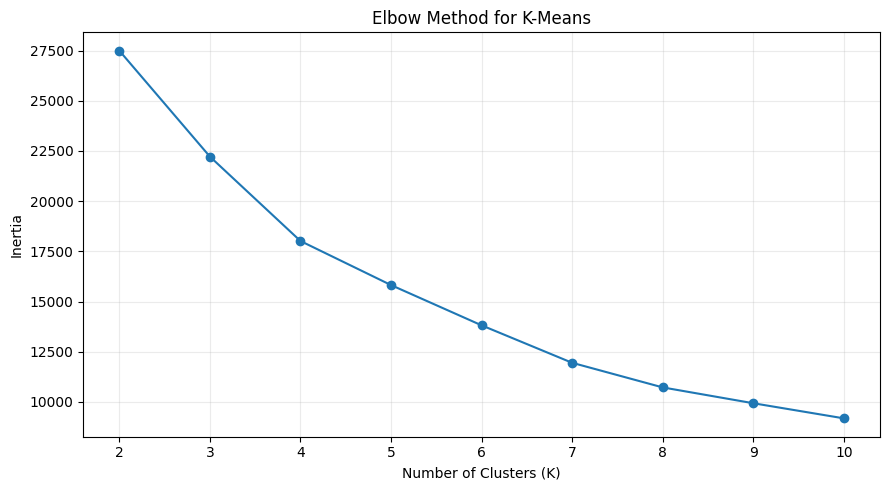

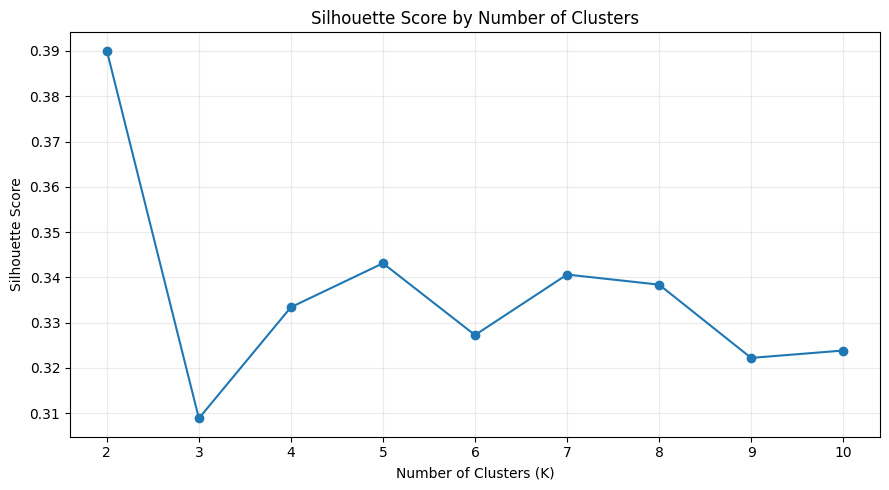

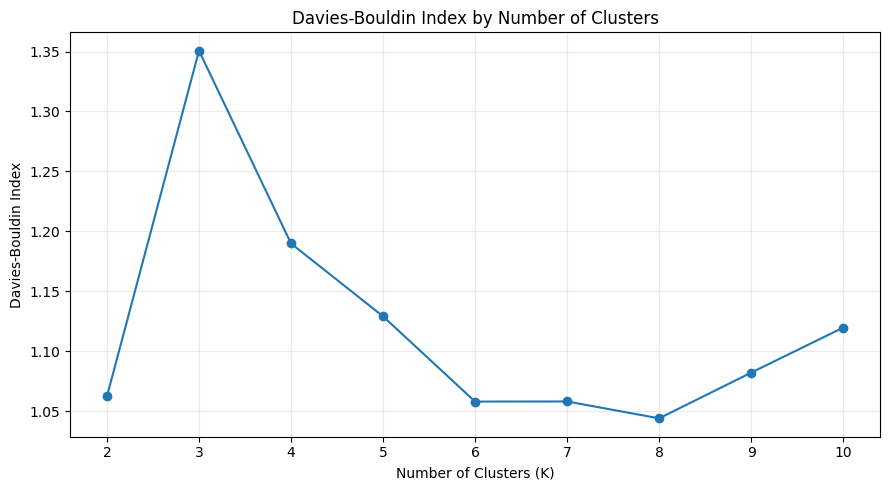

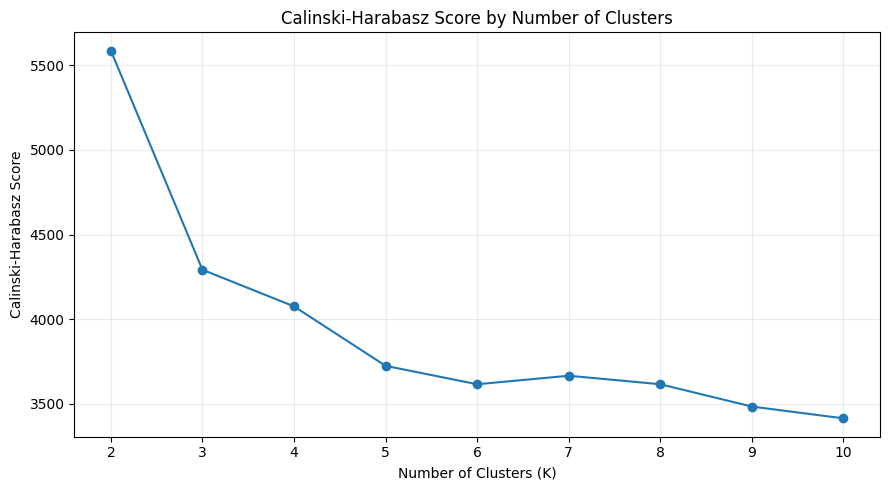


INITIAL FINAL K SELECTION

Selected K based on highest Silhouette Score: 2

Final model metrics:
Silhouette Score: 0.3901
Davies-Bouldin Index: 1.0622
Calinski-Harabasz Score: 5586.3037

CLUSTER SIZES


,Cluster,Customer_Count,Percentage
0,0,2873,40.79
1,1,4170,59.21



CLUSTER PROFILES


SeniorCitizen              tenure               MonthlyCharges         \
                count  mean median  count   mean median          count   mean   
Cluster                                                                         
0                2873  0.22    0.0   2873  49.45   54.0           2873  89.31   
1                4170  0.12    0.0   4170  20.60   13.0           4170  47.85   

               TotalCharges  ...          Num_Services               \
        median        count  ...   median        count  mean median   
Cluster                      ...                                      
0         93.4         2873  ...  4391.45         2873  5.43    5.0   
1         45.8         4170  ...   564.00         4170  1.94    2.0   

        SecuritySupport_Count              Streaming_Count               
                        count  mean median           count  mean median  
Cluster                                                                  
0                        2873  2.36    2.0            2873  1.49    2.0  
1                        4170  0.51    0.0            4170  0.28    0.0  

[2 rows x 21 columns]


Mean profile of each cluster:


...


CHARGES BY CUSTOMER CLUSTER


MonthlyCharges        TotalCharges         
                  mean median         mean   median
Cluster                                            
0                89.31   93.4      4410.58  4391.45
1                47.85   45.8       811.65   564.00


TENURE BY CUSTOMER CLUSTER


,mean,median,min,max
Cluster,,,,
0,49.45,54.0,0,72
1,20.60,13.0,0,72



PCA VISUALIZATION
PC1 explained variance: 59.60%
PC2 explained variance: 15.79%
Combined explained variance: 75.39%


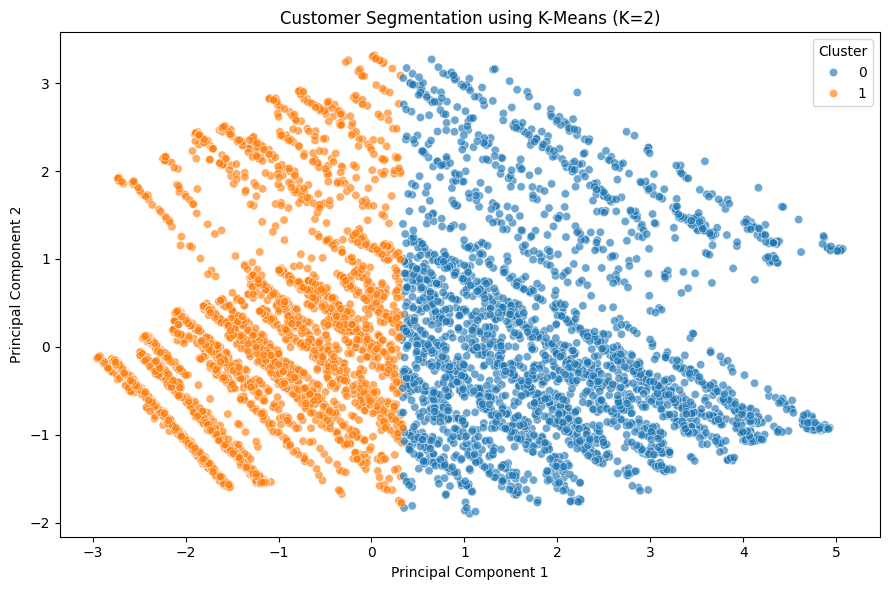


STANDARDIZED CLUSTER CENTERS


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Num_Services,SecuritySupport_Count,Streaming_Count
0,0.151,0.695,0.816,0.940,1.003,0.850,0.843
1,-0.104,-0.479,-0.562,-0.648,-0.691,-0.586,-0.581



CUSTOMER SEGMENTATION COMPLETED

Customers segmented: 7,043
Number of clusters: 2
Final Silhouette Score: 0.3901
Final Davies-Bouldin Index: 1.0622
Final Calinski-Harabasz Score: 5586.3037

Output directory:
/content/drive/MyDrive/VDSWP/week-6/Segmentation_Outputs

Generated files:
 - cluster_centers_scaled.csv
 - cluster_charge_analysis.csv
 - cluster_churn_analysis.csv
 - cluster_profiles_mean.csv
 - cluster_sizes.csv
 - cluster_tenure_analysis.csv
 - customer_segments.csv
 - kmeans_calinski_harabasz_curve.png
 - kmeans_davies_bouldin_curve.png
 - kmeans_elbow_curve.png
 - kmeans_model_selection_metrics.csv
 - kmeans_pca_clusters.png
 - kmeans_silhouette_curve.png

END OF CUSTOMER SEGMENTATION


In [12]:
# ============================================================
# WEEK 6 - STEP 7: CUSTOMER SEGMENTATION USING K-MEANS
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. LOAD FEATURE-ENGINEERED DATA
# ------------------------------------------------------------

feature_file = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "Telco_Customer_Churn_Feature_Engineered.csv"
)

if not os.path.exists(feature_file):
    raise FileNotFoundError(
        f"Feature-engineered dataset not found:\n{feature_file}"
    )

seg_df = pd.read_csv(feature_file)

print("=" * 80)
print("WEEK 6 - CUSTOMER SEGMENTATION USING K-MEANS")
print("=" * 80)

print("\nDataset shape:", seg_df.shape)


# ------------------------------------------------------------
# 2. SELECT SEGMENTATION FEATURES
# ------------------------------------------------------------

segmentation_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count"
]

X_seg = seg_df[segmentation_features].copy()

print("\nSegmentation features:")
print(segmentation_features)

print("\nFeature shape:", X_seg.shape)

print("\nMissing values:")
print(X_seg.isnull().sum())

print("\nBasic statistics:")
display(X_seg.describe().round(2))


# ------------------------------------------------------------
# 3. STANDARDIZE FEATURES
# ------------------------------------------------------------

# K-Means uses distance calculations.
# Standardization prevents high-scale variables such as
# TotalCharges from dominating the distance calculation.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_seg)

print("\nStandardization completed.")

print("\nScaled feature means:")
print(pd.Series(X_scaled.mean(axis=0), index=segmentation_features).round(4))

print("\nScaled feature standard deviations:")
print(pd.Series(X_scaled.std(axis=0), index=segmentation_features).round(4))


# ------------------------------------------------------------
# 4. TEST DIFFERENT VALUES OF K
# ------------------------------------------------------------

k_values = range(2, 11)

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

    davies_bouldin_scores.append(
        davies_bouldin_score(X_scaled, labels)
    )

    calinski_harabasz_scores.append(
        calinski_harabasz_score(X_scaled, labels)
    )


# ------------------------------------------------------------
# 5. CREATE MODEL SELECTION TABLE
# ------------------------------------------------------------

cluster_metrics = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_scores,
    "Davies_Bouldin_Index": davies_bouldin_scores,
    "Calinski_Harabasz_Score": calinski_harabasz_scores
})

print("\n" + "=" * 80)
print("K-MEANS MODEL SELECTION METRICS")
print("=" * 80)

display(
    cluster_metrics.round(4)
)


# ------------------------------------------------------------
# 6. BEST K ACCORDING TO EACH METRIC
# ------------------------------------------------------------

best_silhouette_k = int(
    cluster_metrics.loc[
        cluster_metrics["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_db_k = int(
    cluster_metrics.loc[
        cluster_metrics["Davies_Bouldin_Index"].idxmin(),
        "K"
    ]
)

best_ch_k = int(
    cluster_metrics.loc[
        cluster_metrics["Calinski_Harabasz_Score"].idxmax(),
        "K"
    ]
)

print("\nBest K according to Silhouette Score:",
      best_silhouette_k)

print("Best K according to Davies-Bouldin Index:",
      best_db_k)

print("Best K according to Calinski-Harabasz Score:",
      best_ch_k)


# ------------------------------------------------------------
# 7. ELBOW CURVE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(list(k_values))
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "kmeans_elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. SILHOUETTE SCORE CURVE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(k_values))
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "kmeans_silhouette_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. DAVIES-BOULDIN CURVE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    davies_bouldin_scores,
    marker="o"
)

plt.title("Davies-Bouldin Index by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")

plt.xticks(list(k_values))
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "kmeans_davies_bouldin_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 10. CALINSKI-HARABASZ CURVE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    calinski_harabasz_scores,
    marker="o"
)

plt.title("Calinski-Harabasz Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")

plt.xticks(list(k_values))
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "kmeans_calinski_harabasz_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 11. SELECT FINAL K
# ------------------------------------------------------------

# Primary selection is based on silhouette score.
# We will inspect all metrics and cluster sizes before
# finalizing the interpretation.

final_k = best_silhouette_k

print("\n" + "=" * 80)
print("INITIAL FINAL K SELECTION")
print("=" * 80)

print(f"\nSelected K based on highest Silhouette Score: {final_k}")


# ------------------------------------------------------------
# 12. TRAIN FINAL K-MEANS MODEL
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

seg_df["Cluster"] = final_kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(
    X_scaled,
    seg_df["Cluster"]
)

final_db = davies_bouldin_score(
    X_scaled,
    seg_df["Cluster"]
)

final_ch = calinski_harabasz_score(
    X_scaled,
    seg_df["Cluster"]
)

print("\nFinal model metrics:")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Davies-Bouldin Index: {final_db:.4f}")
print(f"Calinski-Harabasz Score: {final_ch:.4f}")


# ------------------------------------------------------------
# 13. CLUSTER SIZE ANALYSIS
# ------------------------------------------------------------

cluster_sizes = (
    seg_df["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = [
    "Cluster",
    "Customer_Count"
]

cluster_sizes["Percentage"] = (
    cluster_sizes["Customer_Count"]
    / len(seg_df)
    * 100
)

print("\n" + "=" * 80)
print("CLUSTER SIZES")
print("=" * 80)

display(cluster_sizes.round(2))


# ------------------------------------------------------------
# 14. CLUSTER PROFILE
# ------------------------------------------------------------

cluster_profile = (
    seg_df
    .groupby("Cluster")[segmentation_features]
    .agg(["count", "mean", "median"])
)

print("\n" + "=" * 80)
print("CLUSTER PROFILES")
print("=" * 80)

display(cluster_profile.round(2))


# ------------------------------------------------------------
# 15. SIMPLIFIED CLUSTER PROFILE
# ------------------------------------------------------------

cluster_profile_mean = (
    seg_df
    .groupby("Cluster")[segmentation_features]
    .mean()
    .round(2)
)

print("\nMean profile of each cluster:")
display(cluster_profile_mean)


# ------------------------------------------------------------
# 16. INCLUDE CHURN ONLY FOR DESCRIPTIVE ANALYSIS
# ------------------------------------------------------------

# Churn is NOT used to create clusters.
# It is added here only after clustering to understand
# whether the unsupervised segments differ in observed churn.

cluster_churn = (
    seg_df
    .groupby("Cluster")["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

cluster_churn["Churn_Rate_Percent"] = (
    cluster_churn["mean"] * 100
)

print("\n" + "=" * 80)
print("CHURN RATE BY CUSTOMER CLUSTER")
print("=" * 80)

display(
    cluster_churn.round(2)
)


# ------------------------------------------------------------
# 17. MONTHLY CHARGES BY CLUSTER
# ------------------------------------------------------------

cluster_charges = (
    seg_df
    .groupby("Cluster")[[
        "MonthlyCharges",
        "TotalCharges"
    ]]
    .agg(["mean", "median"])
)

print("\n" + "=" * 80)
print("CHARGES BY CUSTOMER CLUSTER")
print("=" * 80)

display(cluster_charges.round(2))


# ------------------------------------------------------------
# 18. TENURE BY CLUSTER
# ------------------------------------------------------------

cluster_tenure = (
    seg_df
    .groupby("Cluster")["tenure"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

print("\n" + "=" * 80)
print("TENURE BY CUSTOMER CLUSTER")
print("=" * 80)

display(cluster_tenure)


# ------------------------------------------------------------
# 19. PCA VISUALIZATION
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": seg_df["Cluster"]
})

explained_variance = pca.explained_variance_ratio_

print("\n" + "=" * 80)
print("PCA VISUALIZATION")
print("=" * 80)

print(
    f"PC1 explained variance: "
    f"{explained_variance[0] * 100:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{explained_variance[1] * 100:.2f}%"
)

print(
    f"Combined explained variance: "
    f"{explained_variance.sum() * 100:.2f}%"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.65
)

plt.title(
    f"Customer Segmentation using K-Means (K={final_k})"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "kmeans_pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 20. STANDARDIZED CLUSTER CENTERS
# ------------------------------------------------------------

cluster_centers_scaled = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=segmentation_features
)

print("\n" + "=" * 80)
print("STANDARDIZED CLUSTER CENTERS")
print("=" * 80)

display(
    cluster_centers_scaled.round(3)
)


# ------------------------------------------------------------
# 21. SAVE RESULTS
# ------------------------------------------------------------

output_dir = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Segmentation_Outputs"
)

os.makedirs(output_dir, exist_ok=True)

# Save clustering metrics
cluster_metrics.to_csv(
    os.path.join(
        output_dir,
        "kmeans_model_selection_metrics.csv"
    ),
    index=False
)

# Save cluster assignments
seg_df.to_csv(
    os.path.join(
        output_dir,
        "customer_segments.csv"
    ),
    index=False
)

# Save cluster sizes
cluster_sizes.to_csv(
    os.path.join(
        output_dir,
        "cluster_sizes.csv"
    ),
    index=False
)

# Save simplified profiles
cluster_profile_mean.to_csv(
    os.path.join(
        output_dir,
        "cluster_profiles_mean.csv"
    )
)

# Save descriptive churn by cluster
cluster_churn.to_csv(
    os.path.join(
        output_dir,
        "cluster_churn_analysis.csv"
    ),
    index=False
)

# Save charge analysis
cluster_charges.to_csv(
    os.path.join(
        output_dir,
        "cluster_charge_analysis.csv"
    )
)

# Save tenure analysis
cluster_tenure.to_csv(
    os.path.join(
        output_dir,
        "cluster_tenure_analysis.csv"
    )
)

# Save cluster centers
cluster_centers_scaled.to_csv(
    os.path.join(
        output_dir,
        "cluster_centers_scaled.csv"
    ),
    index=False
)

# Copy important visualizations into segmentation folder
import shutil

source_dir = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs"
)

for file_name in [
    "kmeans_elbow_curve.png",
    "kmeans_silhouette_curve.png",
    "kmeans_davies_bouldin_curve.png",
    "kmeans_calinski_harabasz_curve.png",
    "kmeans_pca_clusters.png"
]:
    source_path = os.path.join(source_dir, file_name)

    if os.path.exists(source_path):
        shutil.copy2(
            source_path,
            os.path.join(output_dir, file_name)
        )


# ------------------------------------------------------------
# 22. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CUSTOMER SEGMENTATION COMPLETED")
print("=" * 80)

print(f"\nCustomers segmented: {len(seg_df):,}")
print(f"Number of clusters: {final_k}")

print(
    f"Final Silhouette Score: "
    f"{final_silhouette:.4f}"
)

print(
    f"Final Davies-Bouldin Index: "
    f"{final_db:.4f}"
)

print(
    f"Final Calinski-Harabasz Score: "
    f"{final_ch:.4f}"
)

print("\nOutput directory:")
print(output_dir)

print("\nGenerated files:")
for file_name in sorted(os.listdir(output_dir)):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF CUSTOMER SEGMENTATION")
print("=" * 80)


WEEK 6 - SUPERVISED CHURN PREDICTION

Dataset shape: (7043, 28)

Target distribution:
Churn_Binary
No Churn    5174
Churn       1869
Name: count, dtype: int64

Target percentage:
Churn_Binary
No Churn    73.46
Churn       26.54
Name: proportion, dtype: float64

TRAIN / TEST SPLIT
Training samples: 5634
Testing samples: 1409

Training churn rate: 26.54%
Testing churn rate: 26.54%

FEATURE GROUPS

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Num_Services', 'SecuritySupport_Count', 'Streaming_Count', 'Is_New_Customer']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

TRAINING MODELS

Training: Dummy Baseline
Completed.

Training: Logistic Regression
Completed.

Training: Random Forest
Completed.

--------------------------------------------

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Logistic Regression,0.8027,0.6611,0.5267,0.5863,0.8458,0.6525,934,101,177,197
1,Random Forest,0.7786,0.6062,0.4733,0.5315,0.8188,0.6078,920,115,197,177
2,Dummy Baseline,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654,1035,0,374,0


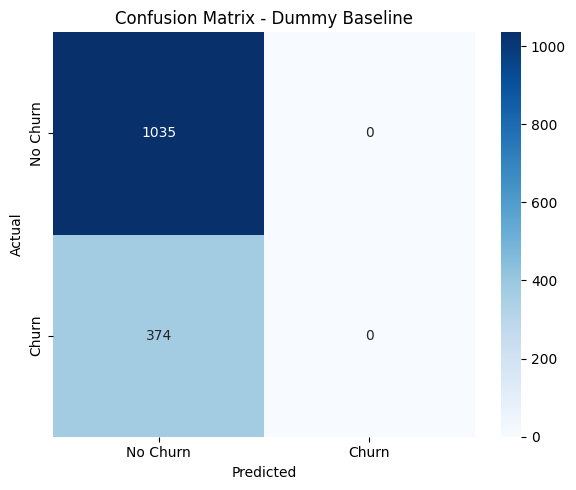

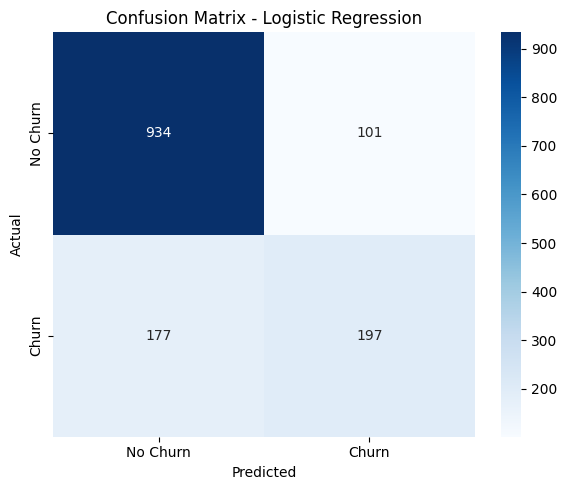

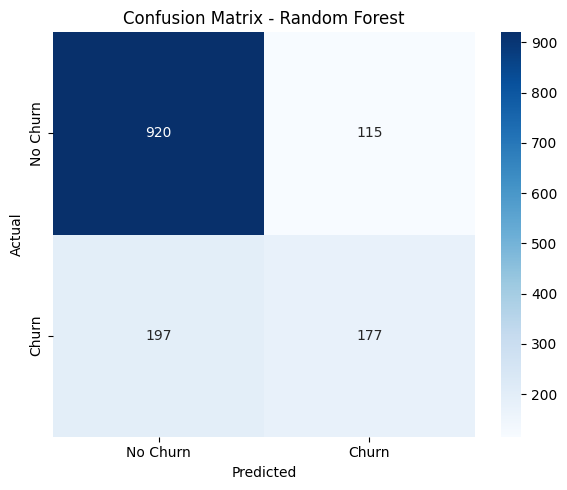

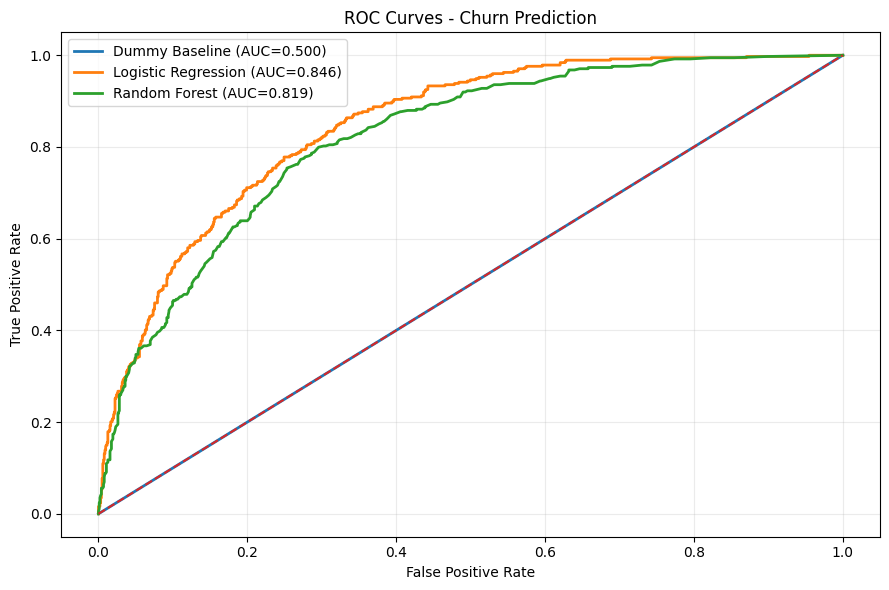

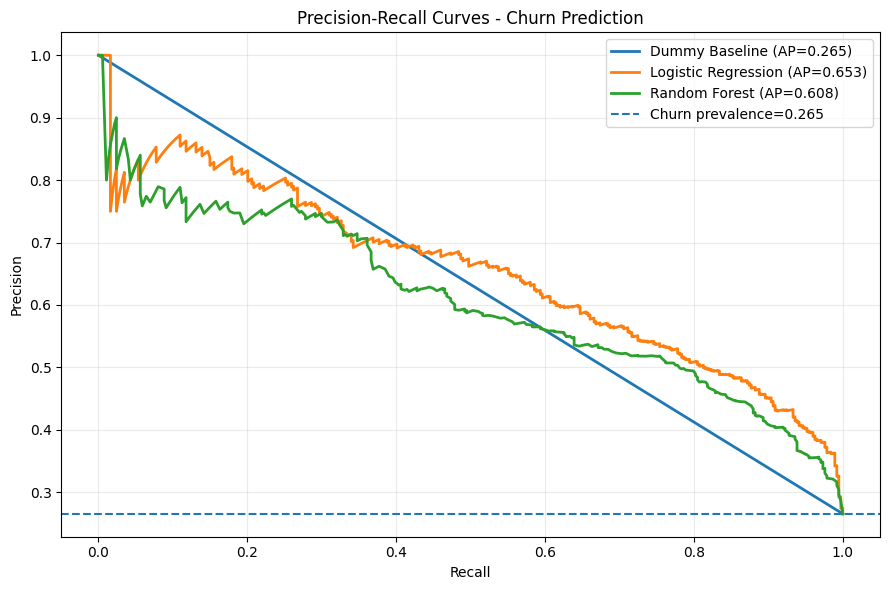


STEP 8 - CHURN PREDICTION COMPLETED

Models trained:
 - Dummy Baseline
 - Logistic Regression
 - Random Forest

Results:


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,Logistic Regression,0.8027,0.6611,0.5267,0.5863,0.8458,0.6525
1,Random Forest,0.7786,0.6062,0.4733,0.5315,0.8188,0.6078
2,Dummy Baseline,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654



Results saved to:
/content/drive/MyDrive/VDSWP/week-6/Churn_Prediction_Outputs

Generated files:
 - churn_test_predictions.csv
 - initial_model_comparison.csv
 - modeling_notes.txt

END OF STEP 8


In [13]:
# ============================================================
# WEEK 6 - STEP 8: SUPERVISED CHURN PREDICTION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# ------------------------------------------------------------
# 1. LOAD FEATURE-ENGINEERED DATA
# ------------------------------------------------------------

feature_file = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "Telco_Customer_Churn_Feature_Engineered.csv"
)

if not os.path.exists(feature_file):
    raise FileNotFoundError(
        f"Feature-engineered dataset not found:\n{feature_file}"
    )

model_df = pd.read_csv(feature_file)

print("=" * 80)
print("WEEK 6 - SUPERVISED CHURN PREDICTION")
print("=" * 80)

print("\nDataset shape:", model_df.shape)


# ------------------------------------------------------------
# 2. DEFINE TARGET
# ------------------------------------------------------------

target = "Churn_Binary"

# Remove identifier and target columns.
# Tenure_Group is excluded because it is a discretized form
# of tenure and would introduce redundant information.
# Above_Median_MonthlyCharge is also excluded because it is
# simply a thresholded version of MonthlyCharges.

drop_columns = [
    "customerID",
    "Churn",
    "Churn_Binary",
    "Tenure_Group",
    "Above_Median_MonthlyCharge"
]

X = model_df.drop(
    columns=drop_columns,
    errors="ignore"
).copy()

y = model_df[target].copy()

print("\nTarget distribution:")
print(
    y.value_counts()
    .rename(index={0: "No Churn", 1: "Churn"})
)

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100)
    .rename(index={0: "No Churn", 1: "Churn"})
    .round(2)
)


# ------------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 80)
print("TRAIN / TEST SPLIT")
print("=" * 80)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining churn rate:",
      f"{y_train.mean() * 100:.2f}%")

print("Testing churn rate:",
      f"{y_test.mean() * 100:.2f}%")


# ------------------------------------------------------------
# 4. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count",
    "Is_New_Customer"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print("\n" + "=" * 80)
print("FEATURE GROUPS")
print("=" * 80)

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# 5. PREPROCESSING PIPELINE
# ------------------------------------------------------------

# Numerical:
# - Median imputation protects against unexpected missing data.
# - StandardScaler is important for Logistic Regression because
#   the numerical variables are on different scales.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical:
# - Most frequent imputation provides a safe fallback.
# - OneHotEncoder converts categories into numerical indicators.
# - handle_unknown="ignore" prevents errors if a category appears
#   in test data that was not present in training data.

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# ------------------------------------------------------------
# 6. DEFINE MODELS
# ------------------------------------------------------------

dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                max_depth=None,
                min_samples_split=2
            )
        )
    ]
)


# ------------------------------------------------------------
# 7. TRAIN MODELS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING MODELS")
print("=" * 80)

models = {
    "Dummy Baseline": dummy_model,
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    print(f"\nTraining: {name}")

    model.fit(
        X_train,
        y_train
    )

    print("Completed.")


# ------------------------------------------------------------
# 8. EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_model(name, model):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    else:
        y_prob = y_pred.astype(float)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\n" + "-" * 80)
    print(name)
    print("-" * 80)

    print(f"Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
    print(f"Recall   : {recall:.4f} ({recall * 100:.2f}%)")
    print(f"F1 Score : {f1:.4f} ({f1 * 100:.2f}%)")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    }, y_pred, y_prob


# ------------------------------------------------------------
# 9. EVALUATE ALL MODELS
# ------------------------------------------------------------

all_results = []
prediction_store = {}

for name, model in models.items():

    result, predictions, probabilities = evaluate_model(
        name,
        model
    )

    all_results.append(result)

    prediction_store[name] = {
        "predictions": predictions,
        "probabilities": probabilities
    }


results_df = pd.DataFrame(
    all_results
)

results_df = results_df.sort_values(
    "F1_Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)

display(
    results_df.round(4)
)


# ------------------------------------------------------------
# 10. CONFUSION MATRICES
# ------------------------------------------------------------

for name, model in models.items():

    predictions = prediction_store[name]["predictions"]

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "No Churn",
            "Churn"
        ],
        yticklabels=[
            "No Churn",
            "Churn"
        ]
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    safe_name = (
        name.lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"/content/drive/MyDrive/VDSWP/week-6/"
        f"Segmentation_Outputs/"
        f"../Churn_Prediction_Outputs_"
        f"{safe_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 11. ROC CURVES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for name in models.keys():

    probabilities = prediction_store[name]["probabilities"]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curves - Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Churn_Prediction_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 12. PRECISION-RECALL CURVES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for name in models.keys():

    probabilities = prediction_store[name]["probabilities"]

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            probabilities
        )
    )

    ap_value = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_value:.3f})"
    )

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Churn prevalence={y_test.mean():.3f}"
)

plt.title("Precision-Recall Curves - Churn Prediction")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Churn_Prediction_PR_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 13. SAVE MODEL RESULTS
# ------------------------------------------------------------

output_dir = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Churn_Prediction_Outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

results_df.to_csv(
    os.path.join(
        output_dir,
        "initial_model_comparison.csv"
    ),
    index=False
)

# Save test predictions from all models
prediction_output = X_test.copy()

prediction_output["Actual_Churn"] = y_test.values

for name in models.keys():

    safe_name = (
        name.lower()
        .replace(" ", "_")
    )

    prediction_output[
        f"{safe_name}_Prediction"
    ] = prediction_store[name]["predictions"]

    prediction_output[
        f"{safe_name}_Probability"
    ] = prediction_store[name]["probabilities"]

prediction_output.to_csv(
    os.path.join(
        output_dir,
        "churn_test_predictions.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 14. SAVE IMPORTANT INFORMATION
# ------------------------------------------------------------

with open(
    os.path.join(
        output_dir,
        "modeling_notes.txt"
    ),
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "Week 6 Churn Prediction Notes\n"
        "===============================\n\n"
        "Problem: Binary customer churn prediction\n"
        "Target: Churn_Binary\n"
        "Split: 80/20 stratified train-test split\n"
        "Random state: 42\n\n"
        "Models:\n"
        "- DummyClassifier (most frequent baseline)\n"
        "- Logistic Regression\n"
        "- Random Forest (300 trees)\n\n"
        "Metrics:\n"
        "- Accuracy\n"
        "- Precision\n"
        "- Recall\n"
        "- F1 Score\n"
        "- ROC-AUC\n"
        "- PR-AUC\n"
    )


# ------------------------------------------------------------
# 15. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STEP 8 - CHURN PREDICTION COMPLETED")
print("=" * 80)

print("\nModels trained:")
for name in models.keys():
    print(" -", name)

print("\nResults:")
display(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nResults saved to:")
print(output_dir)

print("\nGenerated files:")
for file_name in sorted(
    os.listdir(output_dir)
):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF STEP 8")
print("=" * 80)

WEEK 6 - STEP 9: MODEL VALIDATION & IMPROVEMENT

Dataset shape: (7043, 28)

Feature shape: (7043, 23)
Target shape: (7043,)

Training samples: 5634
Testing samples: 1409
Training churn rate: 26.54%
Testing churn rate: 26.54%

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Num_Services', 'SecuritySupport_Count', 'Streaming_Count', 'Is_New_Customer']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

5-FOLD STRATIFIED CROSS-VALIDATION

Running CV for: Logistic Regression
Completed.

Running CV for: Random Forest
Completed.

Cross-validation summary:


,Model,accuracy_Mean,accuracy_Std,precision_Mean,precision_Std,recall_Mean,recall_Std,f1_Mean,f1_Std,roc_auc_Mean,roc_auc_Std,pr_auc_Mean,pr_auc_Std
0,Logistic Regression,0.8078,0.0138,0.6713,0.0308,0.5398,0.0403,0.5979,0.0335,0.8481,0.0113,0.6635,0.0154
1,Random Forest,0.7858,0.0131,0.6235,0.0338,0.4876,0.0283,0.5470,0.0282,0.8227,0.0125,0.6143,0.0289



LOGISTIC REGRESSION HYPERPARAMETER TUNING

Best Logistic Regression parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}

Best cross-validated F1: 0.6360

RANDOM FOREST HYPERPARAMETER TUNING

Best Random Forest parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 250}

Best cross-validated F1: 0.6293

TUNED MODEL TEST-SET EVALUATION

--------------------------------------------------------------------------------
Tuned Logistic Regression
--------------------------------------------------------------------------------
Accuracy: 0.7516
Precision: 0.5212
Recall: 0.7888
F1_Score: 0.6277
ROC_AUC: 0.8451
PR_AUC: 0.6537

Confusion Matrix:
[[764 271]
 [ 79 295]]

--------------------------------------------------------------------------------
Tuned Random Forest
--------------------------------------------------------------------------------
Accuracy: 0.7708
Precision: 0.5548


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Tuned Logistic Regression,0.7516,0.5212,0.7888,0.6277,0.8451,0.6537,764,271,79,295
1,Tuned Random Forest,0.7708,0.5548,0.6898,0.6150,0.8367,0.6444,828,207,116,258



LOGISTIC REGRESSION THRESHOLD ANALYSIS

Best threshold based on out-of-fold F1:


,Threshold,Precision,Recall,F1_Score,Accuracy
16,0.52,0.545,0.7699,0.6382,0.7684



--------------------------------------------------------------------------------
THRESHOLD-ADJUSTED LOGISTIC REGRESSION
--------------------------------------------------------------------------------
Threshold: 0.52
Accuracy : 0.7587
Precision: 0.5314
Recall   : 0.7701
F1 Score : 0.6288
ROC-AUC  : 0.8451
PR-AUC   : 0.6537

Confusion Matrix:
[[781 254]
 [ 86 288]]

FINAL STEP 9 MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Tuned Logistic Regression,0.7516,0.5212,0.7888,0.6277,0.8451,0.6537,764,271,79,295
1,Tuned Random Forest,0.7708,0.5548,0.6898,0.6150,0.8367,0.6444,828,207,116,258
2,Tuned Logistic Regression (Threshold=0.52),0.7587,0.5314,0.7701,0.6288,0.8451,0.6537,781,254,86,288


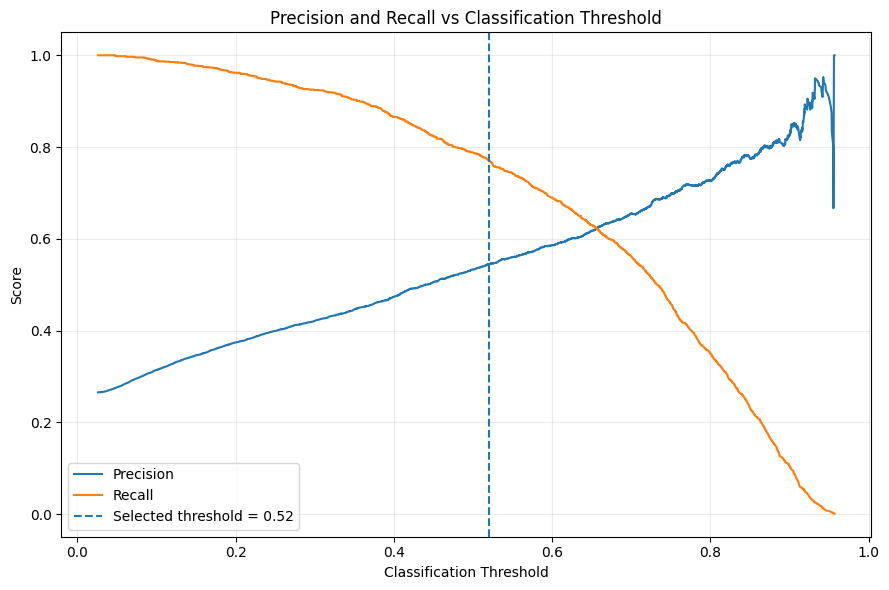

,Model,Best_Parameters,Best_CV_F1
0,Tuned Logistic Regression,"{'classifier__C': 0.01, 'classifier__class_wei...",0.6360
1,Tuned Random Forest,"{'classifier__class_weight': 'balanced', 'clas...",0.6293



STEP 9 COMPLETED

Cross-validation completed: 5 folds

Best Logistic parameters: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}
Best Random Forest parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 250}

Selected Logistic threshold: 0.52

Output directory:
/content/drive/MyDrive/VDSWP/week-6/Model_Validation_Outputs

Generated files:
 - best_model_parameters.csv
 - final_step9_model_comparison.csv
 - five_fold_cross_validation.csv
 - logistic_hyperparameter_results.csv
 - logistic_threshold_analysis.csv
 - precision_recall_threshold_analysis.png
 - random_forest_hyperparameter_results.csv
 - step9_test_predictions.csv
 - tuned_model_test_results.csv

END OF STEP 9


In [14]:
# ============================================================
# WEEK 6 - STEP 9
# CROSS-VALIDATION + HYPERPARAMETER TUNING +
# THRESHOLD ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

feature_file = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "Telco_Customer_Churn_Feature_Engineered.csv"
)

output_dir = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Model_Validation_Outputs"
)

os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------

if not os.path.exists(feature_file):
    raise FileNotFoundError(
        f"Feature-engineered dataset not found:\n{feature_file}"
    )

df = pd.read_csv(feature_file)

print("=" * 80)
print("WEEK 6 - STEP 9: MODEL VALIDATION & IMPROVEMENT")
print("=" * 80)

print("\nDataset shape:", df.shape)


# ------------------------------------------------------------
# 3. DEFINE FEATURES AND TARGET
# ------------------------------------------------------------

target = "Churn_Binary"

drop_columns = [
    "customerID",
    "Churn",
    "Churn_Binary",
    "Tenure_Group",
    "Above_Median_MonthlyCharge"
]

X = df.drop(
    columns=drop_columns,
    errors="ignore"
).copy()

y = df[target].copy()

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    f"Training churn rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Testing churn rate: "
    f"{y_test.mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# 5. FEATURE GROUPS
# ------------------------------------------------------------

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count",
    "Is_New_Customer"
]

categorical_features = [
    col
    for col in X.columns
    if col not in numeric_features
]

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# 6. PREPROCESSING PIPELINE
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 7. DEFINE BASE MODELS
# ------------------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# 8. FIVE-FOLD STRATIFIED CROSS-VALIDATION
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = []

print("\n" + "=" * 80)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 80)

for model_name, model in {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}.items():

    print(f"\nRunning CV for: {model_name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {
        "Model": model_name
    }

    for metric in scoring.keys():

        values = scores[
            f"test_{metric}"
        ]

        row[f"{metric}_Mean"] = values.mean()
        row[f"{metric}_Std"] = values.std()

    cv_results.append(row)

    print("Completed.")

cv_results_df = pd.DataFrame(
    cv_results
)

print("\nCross-validation summary:")
display(
    cv_results_df.round(4)
)

cv_results_df.to_csv(
    os.path.join(
        output_dir,
        "five_fold_cross_validation.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 9. LOGISTIC REGRESSION HYPERPARAMETER TUNING
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION HYPERPARAMETER TUNING")
print("=" * 80)

logistic_param_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1,
        10
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

logistic_grid.fit(
    X_train,
    y_train
)

print("\nBest Logistic Regression parameters:")
print(logistic_grid.best_params_)

print(
    f"\nBest cross-validated F1: "
    f"{logistic_grid.best_score_:.4f}"
)

logistic_cv_results = pd.DataFrame(
    logistic_grid.cv_results_
)

logistic_cv_results[
    [
        "param_classifier__C",
        "param_classifier__class_weight",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
).to_csv(
    os.path.join(
        output_dir,
        "logistic_hyperparameter_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 10. RANDOM FOREST HYPERPARAMETER TUNING
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 80)

random_forest_param_grid = {
    "classifier__n_estimators": [
        150,
        250
    ],
    "classifier__max_depth": [
        None,
        12
    ],
    "classifier__min_samples_leaf": [
        1,
        3
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

random_forest_grid.fit(
    X_train,
    y_train
)

print("\nBest Random Forest parameters:")
print(random_forest_grid.best_params_)

print(
    f"\nBest cross-validated F1: "
    f"{random_forest_grid.best_score_:.4f}"
)

rf_cv_results = pd.DataFrame(
    random_forest_grid.cv_results_
)

rf_cv_results[
    [
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
        "param_classifier__class_weight",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
).to_csv(
    os.path.join(
        output_dir,
        "random_forest_hyperparameter_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 11. TEST-SET EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_pipeline(
    model_name,
    model,
    X_eval,
    y_eval
):

    predictions = model.predict(
        X_eval
    )

    probabilities = model.predict_proba(
        X_eval
    )[:, 1]

    cm = confusion_matrix(
        y_eval,
        predictions
    )

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_eval,
            predictions
        ),
        "Precision": precision_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_eval,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_eval,
            probabilities
        ),
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    }

    print("\n" + "-" * 80)
    print(model_name)
    print("-" * 80)

    for key in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC",
        "PR_AUC"
    ]:
        print(
            f"{key}: "
            f"{results[key]:.4f}"
        )

    print("\nConfusion Matrix:")
    print(cm)

    return (
        results,
        predictions,
        probabilities
    )


# ------------------------------------------------------------
# 12. TEST TUNED MODELS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TUNED MODEL TEST-SET EVALUATION")
print("=" * 80)

tuned_results = []
tuned_predictions = {}
tuned_probabilities = {}

for name, model in {
    "Tuned Logistic Regression":
        logistic_grid.best_estimator_,
    "Tuned Random Forest":
        random_forest_grid.best_estimator_
}.items():

    result, predictions, probabilities = (
        evaluate_pipeline(
            name,
            model,
            X_test,
            y_test
        )
    )

    tuned_results.append(result)

    tuned_predictions[name] = predictions
    tuned_probabilities[name] = probabilities


tuned_results_df = pd.DataFrame(
    tuned_results
)

print("\nTuned model comparison:")
display(
    tuned_results_df.round(4)
)

tuned_results_df.to_csv(
    os.path.join(
        output_dir,
        "tuned_model_test_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 13. THRESHOLD ANALYSIS FOR LOGISTIC REGRESSION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION THRESHOLD ANALYSIS")
print("=" * 80)

# Generate out-of-fold probabilities ONLY from the
# training data. This prevents test-set information from
# being used while choosing the threshold.

oof_probabilities = cross_val_predict(
    logistic_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_values = np.arange(
    0.20,
    0.81,
    0.02
)

threshold_results = []

for threshold in threshold_values:

    oof_predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_train,
            oof_predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["F1_Score"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)

print("\nBest threshold based on out-of-fold F1:")
display(
    best_threshold_row.to_frame().T.round(4)
)

threshold_df.to_csv(
    os.path.join(
        output_dir,
        "logistic_threshold_analysis.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 14. APPLY OPTIMIZED THRESHOLD TO TEST SET
# ------------------------------------------------------------

test_logistic_probabilities = (
    logistic_grid.best_estimator_
    .predict_proba(X_test)[:, 1]
)

threshold_predictions = (
    test_logistic_probabilities >= best_threshold
).astype(int)

threshold_cm = confusion_matrix(
    y_test,
    threshold_predictions
)

threshold_results_test = {
    "Model": (
        "Tuned Logistic Regression "
        f"(Threshold={best_threshold:.2f})"
    ),
    "Accuracy": accuracy_score(
        y_test,
        threshold_predictions
    ),
    "Precision": precision_score(
        y_test,
        threshold_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        threshold_predictions,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        threshold_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_logistic_probabilities
    ),
    "PR_AUC": average_precision_score(
        y_test,
        test_logistic_probabilities
    ),
    "TN": threshold_cm[0, 0],
    "FP": threshold_cm[0, 1],
    "FN": threshold_cm[1, 0],
    "TP": threshold_cm[1, 1]
}

print("\n" + "-" * 80)
print("THRESHOLD-ADJUSTED LOGISTIC REGRESSION")
print("-" * 80)

print(
    f"Threshold: {best_threshold:.2f}"
)

print(
    f"Accuracy : "
    f"{threshold_results_test['Accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{threshold_results_test['Precision']:.4f}"
)

print(
    f"Recall   : "
    f"{threshold_results_test['Recall']:.4f}"
)

print(
    f"F1 Score : "
    f"{threshold_results_test['F1_Score']:.4f}"
)

print(
    f"ROC-AUC  : "
    f"{threshold_results_test['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC   : "
    f"{threshold_results_test['PR_AUC']:.4f}"
)

print("\nConfusion Matrix:")
print(threshold_cm)


# ------------------------------------------------------------
# 15. COMBINE FINAL MODEL RESULTS
# ------------------------------------------------------------

final_model_results = pd.concat(
    [
        tuned_results_df,
        pd.DataFrame(
            [threshold_results_test]
        )
    ],
    ignore_index=True
)

print("\n" + "=" * 80)
print("FINAL STEP 9 MODEL COMPARISON")
print("=" * 80)

display(
    final_model_results[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC",
            "PR_AUC",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ].round(4)
)

final_model_results.to_csv(
    os.path.join(
        output_dir,
        "final_step9_model_comparison.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 16. PRECISION-RECALL THRESHOLD CURVE
# ------------------------------------------------------------

precision_curve, recall_curve, thresholds_curve = (
    precision_recall_curve(
        y_train,
        oof_probabilities
    )
)

plt.figure(figsize=(9, 6))

plt.plot(
    thresholds_curve,
    precision_curve[:-1],
    label="Precision"
)

plt.plot(
    thresholds_curve,
    recall_curve[:-1],
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected threshold = {best_threshold:.2f}"
)

plt.title(
    "Precision and Recall vs Classification Threshold"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "precision_recall_threshold_analysis.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 17. SAVE BEST PARAMETERS
# ------------------------------------------------------------

best_parameters = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Best_Parameters": [
        str(logistic_grid.best_params_),
        str(random_forest_grid.best_params_)
    ],
    "Best_CV_F1": [
        logistic_grid.best_score_,
        random_forest_grid.best_score_
    ]
})

display(
    best_parameters.round(4)
)

best_parameters.to_csv(
    os.path.join(
        output_dir,
        "best_model_parameters.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 18. SAVE TEST PREDICTIONS
# ------------------------------------------------------------

prediction_evidence = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Tuned_Logistic_Prediction":
        tuned_predictions[
            "Tuned Logistic Regression"
        ],
    "Tuned_Logistic_Probability":
        tuned_probabilities[
            "Tuned Logistic Regression"
        ],
    "Tuned_RF_Prediction":
        tuned_predictions[
            "Tuned Random Forest"
        ],
    "Tuned_RF_Probability":
        tuned_probabilities[
            "Tuned Random Forest"
        ],
    "Threshold_Logistic_Prediction":
        threshold_predictions
})

prediction_evidence.to_csv(
    os.path.join(
        output_dir,
        "step9_test_predictions.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 19. STEP 9 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STEP 9 COMPLETED")
print("=" * 80)

print("\nCross-validation completed: 5 folds")

print(
    "\nBest Logistic parameters:",
    logistic_grid.best_params_
)

print(
    "Best Random Forest parameters:",
    random_forest_grid.best_params_
)

print(
    f"\nSelected Logistic threshold: "
    f"{best_threshold:.2f}"
)

print("\nOutput directory:")
print(output_dir)

print("\nGenerated files:")
for file_name in sorted(
    os.listdir(output_dir)
):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF STEP 9")
print("=" * 80)

WEEK 6 - STEP 10: ERROR ANALYSIS & MODEL INTERPRETATION

Feature-engineered dataset: (7043, 28)
Prediction evidence: (1409, 6)

1. PREDICTION TYPE COUNTS


,Count
Prediction_Type,
True Negative,764
True Positive,295
False Positive,271
False Negative,79



Confusion Matrix:
[[764 271]
 [ 79 295]]

TN: 764
FP: 271
FN: 79
TP: 295

Total classification errors: 350
Error rate: 24.84%

2. FALSE NEGATIVE ANALYSIS
False negatives: 79


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Num_Services,Is_New_Customer,Churn_Probability
39,4701-MLJPN,31,55.25,1715.65,Month-to-month,DSL,Electronic check,3,0,0.385372
61,3705-PSNGL,45,20.40,930.45,One year,No,Electronic check,1,0,0.132526
67,7410-KTVFV,18,49.55,878.35,Month-to-month,DSL,Mailed check,2,0,0.448453
68,9033-EOXWV,12,74.05,872.65,One year,DSL,Mailed check,5,0,0.397825
82,9254-RBFON,17,98.60,1704.95,One year,Fiber optic,Bank transfer (automatic),5,0,0.422990
104,4695-VADHF,18,57.45,990.85,Month-to-month,DSL,Electronic check,3,0,0.471623
130,1963-VAUKV,1,20.40,20.40,Month-to-month,No,Mailed check,1,1,0.394740
165,2839-RFSQE,2,20.65,38.70,Month-to-month,No,Mailed check,1,1,0.390907
167,8849-GYOKR,54,106.55,5763.30,One year,Fiber optic,Bank transfer (automatic),6,0,0.309538
173,5766-ZJYBB,1,19.40,19.40,Month-to-month,No,Mailed check,1,1,0.398552



False-negative profile:


...

,Feature,Coefficient,Absolute_Coefficient
40,cat__Contract_Month-to-month,0.4862,0.4862
20,cat__InternetService_Fiber optic,0.3172,0.3172
7,num__Is_New_Customer,0.3039,0.3039
2,num__MonthlyCharges,0.2735,0.2735
47,cat__PaymentMethod_Electronic check,0.2547,0.2547
22,cat__OnlineSecurity_No,0.1901,0.1901
31,cat__TechSupport_No,0.1742,0.1742
44,cat__PaperlessBilling_Yes,0.1589,0.1589
6,num__Streaming_Count,0.1450,0.1450
12,cat__Dependents_No,0.0978,0.0978



Features associated with lower predicted churn:


,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-0.4266,0.4266
42,cat__Contract_Two year,-0.4115,0.4115
19,cat__InternetService_DSL,-0.2397,0.2397
43,cat__PaperlessBilling_No,-0.1592,0.1592
16,cat__MultipleLines_No,-0.1492,0.1492
5,num__SecuritySupport_Count,-0.1315,0.1315
3,num__TotalCharges,-0.1211,0.1211
24,cat__OnlineSecurity_Yes,-0.1126,0.1126
13,cat__Dependents_Yes,-0.0981,0.0981
33,cat__TechSupport_Yes,-0.0967,0.0967



11. RANDOM FOREST - TOP FEATURES


,Feature,Importance
40,cat__Contract_Month-to-month,0.1169
1,num__tenure,0.1115
3,num__TotalCharges,0.1009
2,num__MonthlyCharges,0.0864
42,cat__Contract_Two year,0.0499
22,cat__OnlineSecurity_No,0.0473
31,cat__TechSupport_No,0.0413
20,cat__InternetService_Fiber optic,0.0368
47,cat__PaymentMethod_Electronic check,0.0327
7,num__Is_New_Customer,0.0238


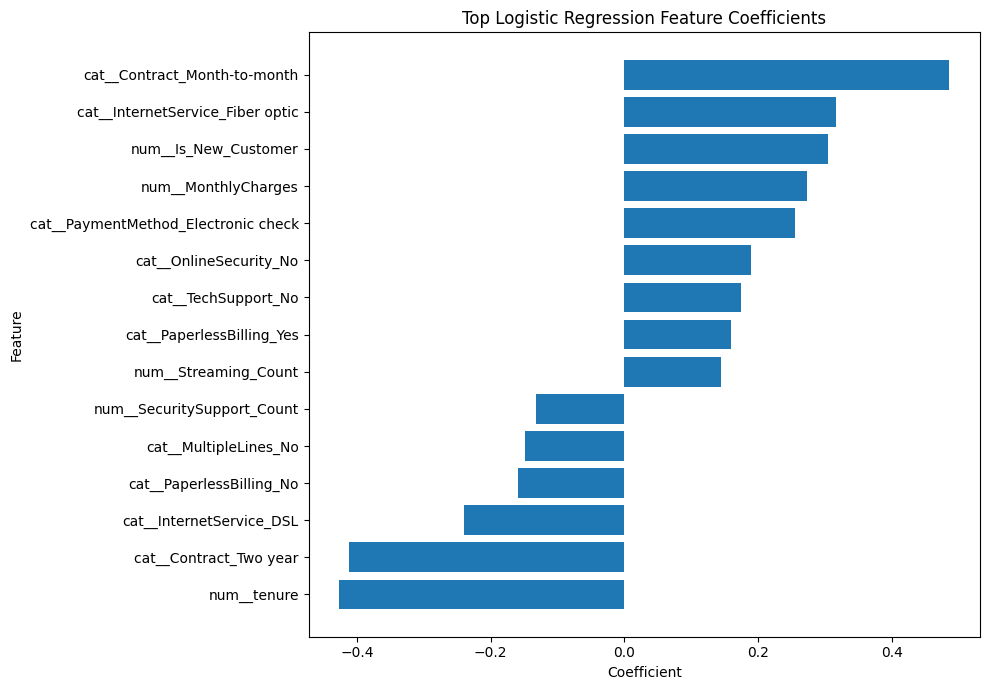

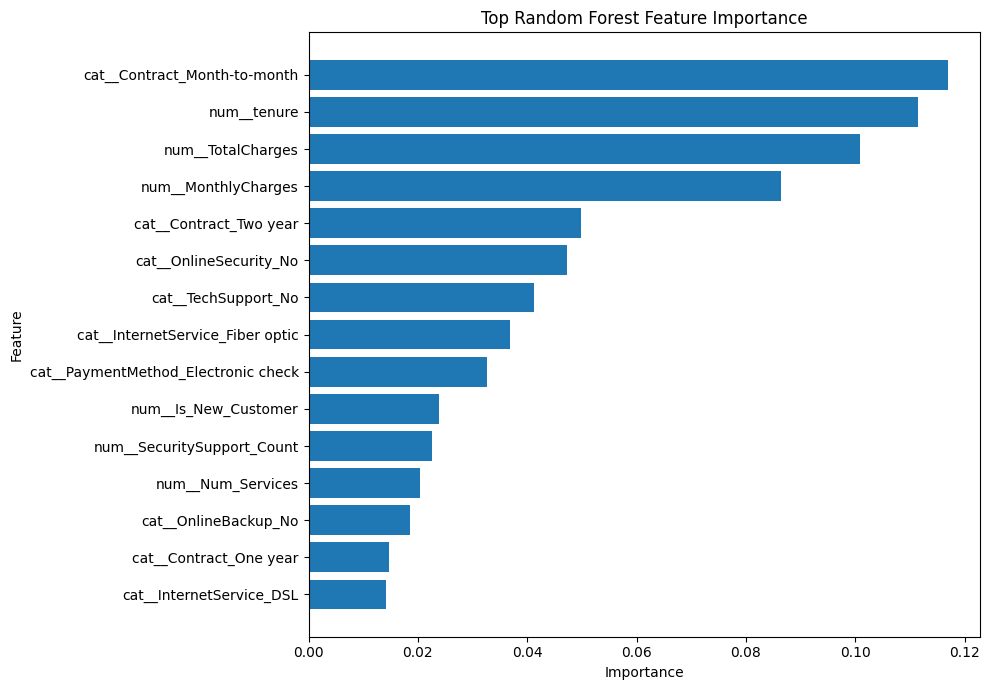


STEP 10 COMPLETED

Test observations analyzed: 1409
True Positives: 295
True Negatives: 764
False Positives: 271
False Negatives: 79
Total errors: 350

False Negative Rate among actual churners: 21.12%
False Positive Rate among actual non-churners: 26.18%

Output directory:
/content/drive/MyDrive/VDSWP/week-6/Error_Analysis_Outputs

Generated files:
 - complete_test_error_analysis.csv
 - error_rate_by_contract.csv
 - error_rate_by_customer_cluster.csv
 - error_rate_by_internet_service.csv
 - error_rate_by_payment_method.csv
 - error_rate_by_tenure_group.csv
 - false_negative_cases.csv
 - false_positive_cases.csv
 - logistic_feature_coefficients.csv
 - prediction_type_profiles.csv
 - random_forest_feature_importance.csv
 - top_logistic_feature_coefficients.png
 - top_random_forest_feature_importance.png

END OF STEP 10


In [15]:
# ============================================================
# WEEK 6 - STEP 10
# ERROR ANALYSIS + MODEL INTERPRETATION
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

feature_file = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Feature_Engineering_Outputs/"
    "Telco_Customer_Churn_Feature_Engineered.csv"
)

prediction_file = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Model_Validation_Outputs/"
    "step9_test_predictions.csv"
)

segment_file = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Segmentation_Outputs/"
    "customer_segments.csv"
)

output_dir = (
    "/content/drive/MyDrive/VDSWP/week-6/"
    "Error_Analysis_Outputs"
)

os.makedirs(output_dir, exist_ok=True)

print("=" * 80)
print("WEEK 6 - STEP 10: ERROR ANALYSIS & MODEL INTERPRETATION")
print("=" * 80)


# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(feature_file)
pred_df = pd.read_csv(prediction_file)

print("\nFeature-engineered dataset:", df.shape)
print("Prediction evidence:", pred_df.shape)


# ------------------------------------------------------------
# 3. RECREATE THE SAME TRAIN/TEST SPLIT
# ------------------------------------------------------------

target = "Churn_Binary"

drop_columns = [
    "customerID",
    "Churn",
    "Churn_Binary",
    "Tenure_Group",
    "Above_Median_MonthlyCharge"
]

X = df.drop(
    columns=drop_columns,
    errors="ignore"
)

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Test indices are preserved from the original dataframe.
test_indices = X_test.index

analysis_df = df.loc[
    test_indices
].copy()

analysis_df = analysis_df.reset_index(
    drop=True
)

# Add saved predictions from Step 9
analysis_df["Actual_Churn"] = pred_df[
    "Actual_Churn"
].values

analysis_df["Predicted_Churn"] = pred_df[
    "Tuned_Logistic_Prediction"
].values

analysis_df["Churn_Probability"] = pred_df[
    "Tuned_Logistic_Probability"
].values

analysis_df["Threshold_Prediction"] = pred_df[
    "Threshold_Logistic_Prediction"
].values


# ------------------------------------------------------------
# 4. CLASSIFY EACH TEST OBSERVATION
# ------------------------------------------------------------

def classify_prediction(row):

    actual = row["Actual_Churn"]
    predicted = row["Predicted_Churn"]

    if actual == 1 and predicted == 1:
        return "True Positive"

    elif actual == 0 and predicted == 0:
        return "True Negative"

    elif actual == 0 and predicted == 1:
        return "False Positive"

    else:
        return "False Negative"


analysis_df["Prediction_Type"] = (
    analysis_df.apply(
        classify_prediction,
        axis=1
    )
)

print("\n" + "=" * 80)
print("1. PREDICTION TYPE COUNTS")
print("=" * 80)

prediction_counts = (
    analysis_df["Prediction_Type"]
    .value_counts()
)

display(
    prediction_counts
    .to_frame("Count")
)


# ------------------------------------------------------------
# 5. CONFUSION MATRIX FROM SAVED PREDICTIONS
# ------------------------------------------------------------

cm = confusion_matrix(
    analysis_df["Actual_Churn"],
    analysis_df["Predicted_Churn"]
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

error_count = fp + fn

print(
    f"\nTotal classification errors: "
    f"{error_count}"
)

print(
    f"Error rate: "
    f"{error_count / len(analysis_df) * 100:.2f}%"
)


# ------------------------------------------------------------
# 6. FALSE NEGATIVE ANALYSIS
# ------------------------------------------------------------

false_negatives = analysis_df[
    analysis_df["Prediction_Type"]
    == "False Negative"
].copy()

print("\n" + "=" * 80)
print("2. FALSE NEGATIVE ANALYSIS")
print("=" * 80)

print(
    f"False negatives: "
    f"{len(false_negatives)}"
)

if len(false_negatives) > 0:

    display(
        false_negatives[
            [
                "customerID",
                "tenure",
                "MonthlyCharges",
                "TotalCharges",
                "Contract",
                "InternetService",
                "PaymentMethod",
                "Num_Services",
                "Is_New_Customer",
                "Churn_Probability"
            ]
        ].head(20)
    )

    false_negative_summary = pd.DataFrame({
        "Mean_Tenure": [
            false_negatives["tenure"].mean()
        ],
        "Median_Tenure": [
            false_negatives["tenure"].median()
        ],
        "Mean_MonthlyCharges": [
            false_negatives["MonthlyCharges"].mean()
        ],
        "Mean_TotalCharges": [
            false_negatives["TotalCharges"].mean()
        ],
        "New_Customer_Percentage": [
            false_negatives["Is_New_Customer"].mean() * 100
        ]
    })

    print("\nFalse-negative profile:")
    display(
        false_negative_summary.round(2)
    )


# ------------------------------------------------------------
# 7. FALSE POSITIVE ANALYSIS
# ------------------------------------------------------------

false_positives = analysis_df[
    analysis_df["Prediction_Type"]
    == "False Positive"
].copy()

print("\n" + "=" * 80)
print("3. FALSE POSITIVE ANALYSIS")
print("=" * 80)

print(
    f"False positives: "
    f"{len(false_positives)}"
)

if len(false_positives) > 0:

    display(
        false_positives[
            [
                "customerID",
                "tenure",
                "MonthlyCharges",
                "TotalCharges",
                "Contract",
                "InternetService",
                "PaymentMethod",
                "Num_Services",
                "Is_New_Customer",
                "Churn_Probability"
            ]
        ].head(20)
    )


# ------------------------------------------------------------
# 8. PROFILE COMPARISON: TP / FN / FP / TN
# ------------------------------------------------------------

profile_summary = (
    analysis_df
    .groupby("Prediction_Type")
    .agg(
        Customers=("customerID", "count"),
        Mean_Tenure=("tenure", "mean"),
        Median_Tenure=("tenure", "median"),
        Mean_MonthlyCharges=("MonthlyCharges", "mean"),
        Median_MonthlyCharges=("MonthlyCharges", "median"),
        Mean_TotalCharges=("TotalCharges", "mean"),
        Mean_Num_Services=("Num_Services", "mean"),
        New_Customer_Percent=("Is_New_Customer", "mean")
    )
)

profile_summary["New_Customer_Percent"] *= 100

print("\n" + "=" * 80)
print("4. PROFILE BY PREDICTION TYPE")
print("=" * 80)

display(
    profile_summary.round(2)
)

profile_summary.to_csv(
    os.path.join(
        output_dir,
        "prediction_type_profiles.csv"
    )
)


# ------------------------------------------------------------
# 9. ERROR RATE BY TENURE GROUP
# ------------------------------------------------------------

tenure_error = (
    analysis_df
    .groupby("Tenure_Group", observed=False)
    .agg(
        Customers=("customerID", "count"),
        Errors=("Prediction_Type",
                lambda x:
                ((x == "False Positive") |
                 (x == "False Negative")).sum())
    )
    .reset_index()
)

tenure_error["Error_Rate_Percent"] = (
    tenure_error["Errors"]
    / tenure_error["Customers"]
    * 100
)

print("\n" + "=" * 80)
print("5. ERROR RATE BY TENURE GROUP")
print("=" * 80)

display(
    tenure_error.round(2)
)

tenure_error.to_csv(
    os.path.join(
        output_dir,
        "error_rate_by_tenure_group.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 10. ERROR RATE BY CONTRACT
# ------------------------------------------------------------

contract_error = (
    analysis_df
    .groupby("Contract")
    .agg(
        Customers=("customerID", "count"),
        Errors=("Prediction_Type",
                lambda x:
                ((x == "False Positive") |
                 (x == "False Negative")).sum())
    )
    .reset_index()
)

contract_error["Error_Rate_Percent"] = (
    contract_error["Errors"]
    / contract_error["Customers"]
    * 100
)

print("\n" + "=" * 80)
print("6. ERROR RATE BY CONTRACT")
print("=" * 80)

display(
    contract_error.round(2)
)

contract_error.to_csv(
    os.path.join(
        output_dir,
        "error_rate_by_contract.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 11. ERROR RATE BY INTERNET SERVICE
# ------------------------------------------------------------

internet_error = (
    analysis_df
    .groupby("InternetService")
    .agg(
        Customers=("customerID", "count"),
        Errors=("Prediction_Type",
                lambda x:
                ((x == "False Positive") |
                 (x == "False Negative")).sum())
    )
    .reset_index()
)

internet_error["Error_Rate_Percent"] = (
    internet_error["Errors"]
    / internet_error["Customers"]
    * 100
)

print("\n" + "=" * 80)
print("7. ERROR RATE BY INTERNET SERVICE")
print("=" * 80)

display(
    internet_error.round(2)
)

internet_error.to_csv(
    os.path.join(
        output_dir,
        "error_rate_by_internet_service.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 12. ERROR RATE BY PAYMENT METHOD
# ------------------------------------------------------------

payment_error = (
    analysis_df
    .groupby("PaymentMethod")
    .agg(
        Customers=("customerID", "count"),
        Errors=("Prediction_Type",
                lambda x:
                ((x == "False Positive") |
                 (x == "False Negative")).sum())
    )
    .reset_index()
)

payment_error["Error_Rate_Percent"] = (
    payment_error["Errors"]
    / payment_error["Customers"]
    * 100
)

print("\n" + "=" * 80)
print("8. ERROR RATE BY PAYMENT METHOD")
print("=" * 80)

display(
    payment_error.round(2)
)

payment_error.to_csv(
    os.path.join(
        output_dir,
        "error_rate_by_payment_method.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 13. ERROR RATE BY CUSTOMER CLUSTER
# ------------------------------------------------------------

if os.path.exists(segment_file):

    segment_df = pd.read_csv(
        segment_file
    )

    if "customerID" in segment_df.columns:

        cluster_lookup = segment_df[
            ["customerID", "Cluster"]
        ].copy()

        analysis_df = analysis_df.merge(
            cluster_lookup,
            on="customerID",
            how="left"
        )

        cluster_error = (
            analysis_df
            .groupby("Cluster")
            .agg(
                Customers=("customerID", "count"),
                Errors=("Prediction_Type",
                        lambda x:
                        ((x == "False Positive") |
                         (x == "False Negative")).sum()),
                Mean_Churn_Probability=(
                    "Churn_Probability",
                    "mean"
                )
            )
            .reset_index()
        )

        cluster_error["Error_Rate_Percent"] = (
            cluster_error["Errors"]
            / cluster_error["Customers"]
            * 100
        )

        print("\n" + "=" * 80)
        print("9. ERROR RATE BY CUSTOMER CLUSTER")
        print("=" * 80)

        display(
            cluster_error.round(2)
        )

        cluster_error.to_csv(
            os.path.join(
                output_dir,
                "error_rate_by_customer_cluster.csv"
            ),
            index=False
        )


# ------------------------------------------------------------
# 14. RECREATE TUNED LOGISTIC MODEL FOR INTERPRETABILITY
# ------------------------------------------------------------

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Num_Services",
    "SecuritySupport_Count",
    "Streaming_Count",
    "Is_New_Customer"
]

categorical_features = [
    col
    for col in X.columns
    if col not in numeric_features
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

interpretable_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                C=0.01,
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Fit only for coefficient interpretation.
interpretable_logistic.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 15. LOGISTIC REGRESSION COEFFICIENT ANALYSIS
# ------------------------------------------------------------

fitted_preprocessor = (
    interpretable_logistic
    .named_steps["preprocessor"]
)

fitted_classifier = (
    interpretable_logistic
    .named_steps["classifier"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficients = (
    fitted_classifier
    .coef_[0]
)

logistic_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

logistic_importance = (
    logistic_importance
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

print("\n" + "=" * 80)
print("10. LOGISTIC REGRESSION - TOP FEATURES")
print("=" * 80)

print("\nTop 20 features by absolute coefficient:")
display(
    logistic_importance.head(20).round(4)
)

print("\nFeatures associated with higher predicted churn:")
display(
    logistic_importance[
        logistic_importance["Coefficient"] > 0
    ].head(10).round(4)
)

print("\nFeatures associated with lower predicted churn:")
display(
    logistic_importance[
        logistic_importance["Coefficient"] < 0
    ].head(10).round(4)
)

logistic_importance.to_csv(
    os.path.join(
        output_dir,
        "logistic_feature_coefficients.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 16. RANDOM FOREST FEATURE IMPORTANCE
# ------------------------------------------------------------

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]
            ),
            numeric_features
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_features
        )
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=None,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Fit only for feature importance interpretation.
rf_model.fit(
    X_train,
    y_train
)

rf_fitted_preprocessor = (
    rf_model
    .named_steps["preprocessor"]
)

rf_classifier = (
    rf_model
    .named_steps["classifier"]
)

rf_feature_names = (
    rf_fitted_preprocessor
    .get_feature_names_out()
)

rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_classifier.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("\n" + "=" * 80)
print("11. RANDOM FOREST - TOP FEATURES")
print("=" * 80)

display(
    rf_importance.head(20).round(4)
)

rf_importance.to_csv(
    os.path.join(
        output_dir,
        "random_forest_feature_importance.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 17. PLOT TOP LOGISTIC FEATURES
# ------------------------------------------------------------

top_logistic = (
    logistic_importance
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_logistic["Feature"],
    top_logistic["Coefficient"]
)

plt.title(
    "Top Logistic Regression Feature Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "top_logistic_feature_coefficients.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 18. PLOT TOP RANDOM FOREST FEATURES
# ------------------------------------------------------------

top_rf = (
    rf_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.title(
    "Top Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "top_random_forest_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 19. SAVE FALSE POSITIVE / FALSE NEGATIVE RECORDS
# ------------------------------------------------------------

false_negatives.to_csv(
    os.path.join(
        output_dir,
        "false_negative_cases.csv"
    ),
    index=False
)

false_positives.to_csv(
    os.path.join(
        output_dir,
        "false_positive_cases.csv"
    ),
    index=False
)

analysis_df.to_csv(
    os.path.join(
        output_dir,
        "complete_test_error_analysis.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 20. FINAL ERROR ANALYSIS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STEP 10 COMPLETED")
print("=" * 80)

print(f"\nTest observations analyzed: {len(analysis_df)}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"Total errors: {error_count}")

print(
    f"\nFalse Negative Rate among actual churners: "
    f"{fn / (fn + tp) * 100:.2f}%"
)

print(
    f"False Positive Rate among actual non-churners: "
    f"{fp / (fp + tn) * 100:.2f}%"
)

print("\nOutput directory:")
print(output_dir)

print("\nGenerated files:")

for file_name in sorted(
    os.listdir(output_dir)
):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF STEP 10")
print("=" * 80)

WEEK 6 - STEP 11: INSIGHTS & RECOMMENDATIONS

1. KEY CATEGORICAL CHURN PATTERNS


,Variable,Churn_Rate_Percent,count,sum,Overall_Churn_Difference
41,PaymentMethod,45.29,2365,1071,18.75
34,Contract,42.71,3875,1655,16.17
14,InternetService,41.89,3096,1297,15.36
16,OnlineSecurity,41.77,3498,1461,15.23
3,SeniorCitizen,41.68,1142,476,15.14
25,TechSupport,41.64,3473,1446,15.10
19,OnlineBackup,39.93,3088,1233,13.39
22,DeviceProtection,39.13,3095,1211,12.59
38,PaperlessBilling,33.57,4171,1400,7.03
4,Partner,32.96,3641,1200,6.42



2. STRONGEST CATEGORICAL ASSOCIATIONS


,Feature,Chi_Square,p_value,Cramers_V
0,Contract,1184.5966,0.0,0.4101
1,OnlineSecurity,849.9990,0.0,0.3474
2,TechSupport,828.1971,0.0,0.3429
3,InternetService,732.3096,0.0,0.3225
4,PaymentMethod,648.1423,0.0,0.3034
5,OnlineBackup,601.8128,0.0,0.2923
6,DeviceProtection,558.4194,0.0,0.2816
7,StreamingMovies,375.6615,0.0,0.2310
8,StreamingTV,374.2039,0.0,0.2305
9,PaperlessBilling,258.2776,0.0,0.1915



3. NUMERICAL DIFFERENCES


...

,Insight_ID,Area,Evidence,Interpretation,Caution
0,I1,Overall churn,26.54% of customers churned.,"Churn is a substantial outcome class, so model...",This describes the observed dataset and is not...
1,I2,Customer lifecycle,Mean tenure is 17.98 months for churned custom...,Shorter-tenure customers show a stronger assoc...,This is an association and does not prove that...
2,I3,New customers,Customers in the 0-6 month group have a 52.94%...,The first six months are an important customer...,This is a descriptive comparison.
3,I4,Contract,"Month-to-month churn = 42.71%, one-year = 11.2...",Contract type is strongly associated with obse...,The analysis does not establish a causal effec...
4,I5,Internet service,"Fiber optic churn = 41.89%, DSL = 18.96%, no i...",Internet service type separates customer group...,"Service type may interact with contract, prici..."
5,I6,Payment method,"Electronic-check churn = 45.29%, automatic ban...",Payment method is a strong descriptive separat...,Payment method should not be interpreted as a ...
6,I7,Charges,Mean monthly charges are 74.44 for churned cus...,Churned customers have higher average monthly ...,Charges are related to subscribed services and...
7,I8,Customer segmentation,K-Means produced two segments with different t...,Unsupervised segmentation adds a descriptive c...,Churn was not used when creating the clusters.
8,I9,Model errors,The tuned Logistic Regression produced 79 fals...,The model still has uncertainty for a meaningf...,The appropriate error balance depends on the o...



9. EVIDENCE-BASED RECOMMENDATIONS


,Recommendation_ID,Area,Recommendation,Evidence,Potential_Action,Trade_Off
0,R1,Early lifecycle,Use stronger onboarding and early-tenure engag...,0-6 month churn rate = 52.94%.,"Provide structured onboarding, service educati...",Requires additional support or engagement reso...
1,R2,Contract,Analyze month-to-month customers as a distinct...,Month-to-month churn rate = 42.71%.,Evaluate contract education and retention offe...,Incentives may affect short-term revenue or ma...
2,R3,Payment experience,Investigate customer and billing characteristi...,Electronic-check churn rate = 45.29%.,"Study billing communication, payment experienc...",Any payment-method change requires careful com...
3,R4,Support and security,Evaluate support and security-service adoption...,Customers without OnlineSecurity and TechSuppo...,"Test targeted service education, support avail...",Additional services can increase customer cost.
4,R5,Predictive deployment,Use churn probabilities and validated threshol...,The final model generates both false positives...,Define risk bands and choose thresholds using ...,Higher recall can increase the number of custo...



10. FURTHER ANALYSIS


,Area,Why,Proposed_Method
0,Threshold optimization,False negatives and false positives may have d...,Select the threshold using explicit operationa...
1,Probability calibration,Predicted probabilities may be used to priorit...,Evaluate calibration curves and Brier score.
2,Interaction effects,"Contract, tenure, service type, and charges ma...",Test interactions or nonlinear models using cr...
3,Explainability,Operational users may need explanations for pr...,Evaluate permutation importance or SHAP.
4,Segment-specific analysis,The two customer clusters have different profi...,Test segment-specific thresholds or models.
5,Cost-sensitive modeling,Missed churn and unnecessary outreach can have...,Define a cost matrix and compare models using ...


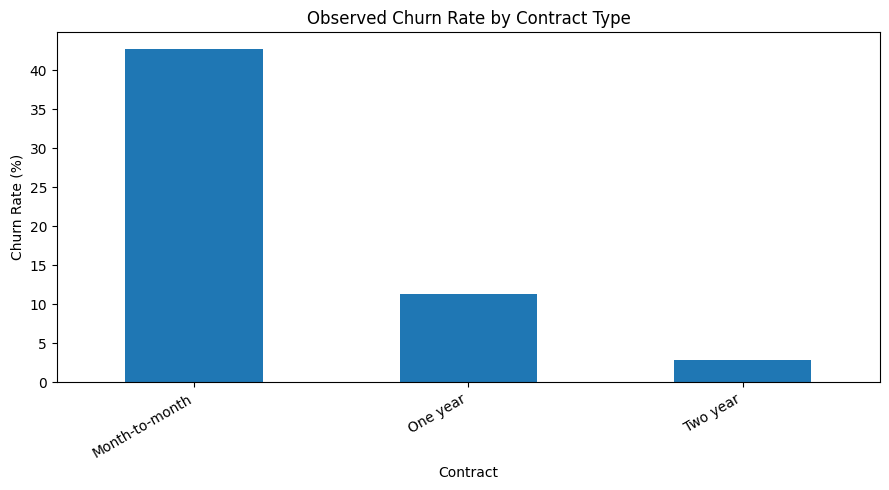

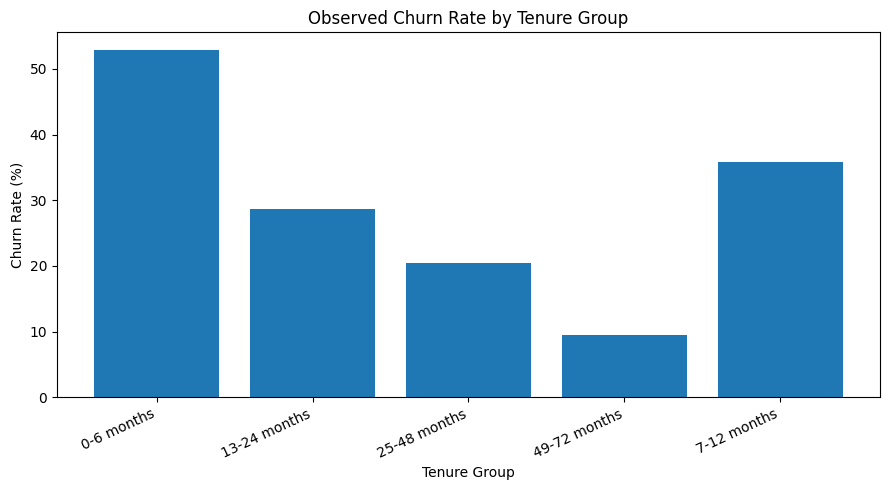

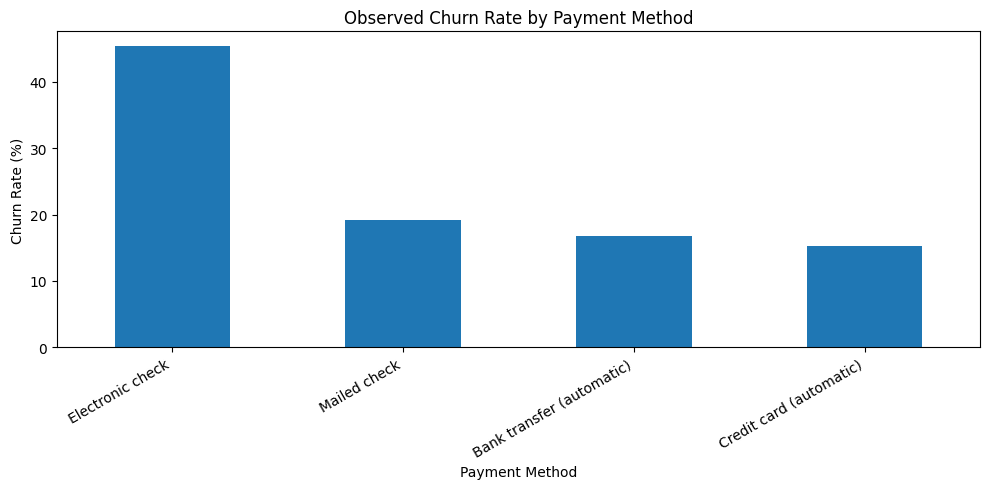

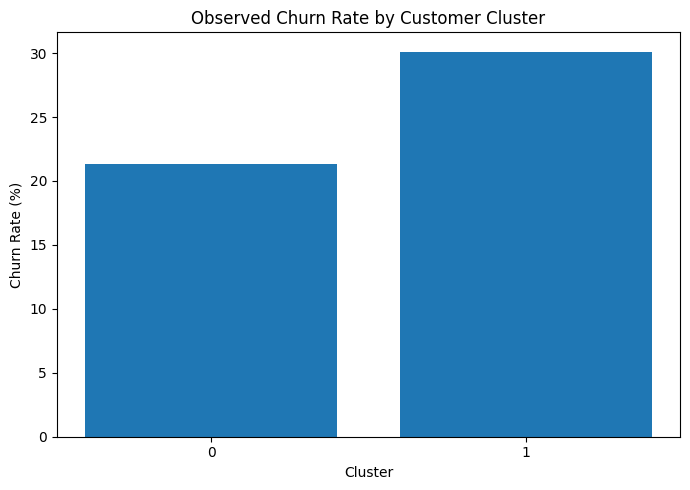


STEP 11 COMPLETED SUCCESSFULLY

Output directory:
/content/drive/MyDrive/VDSWP/week-6/Insights_Outputs

Generated files:
 - Week6_Insights_Summary.txt
 - cluster_insight_summary.csv
 - evidence_based_insights.csv
 - evidence_based_recommendations.csv
 - further_analysis_plan.csv
 - insight_cluster_churn.png
 - insight_contract_churn.png
 - insight_payment_churn.png
 - insight_tenure_churn.png
 - key_categorical_patterns.csv
 - new_customer_insight.csv
 - top_categorical_associations.csv

END OF STEP 11


In [18]:
# ============================================================
# WEEK 6 - STEP 11
# INSIGHTS, RECOMMENDATIONS & FURTHER ANALYSIS
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DEFINE ALL PATHS
# ------------------------------------------------------------

base_dir = "/content/drive/MyDrive/VDSWP/week-6"

eda_dir = os.path.join(base_dir, "EDA_Outputs")
seg_dir = os.path.join(base_dir, "Segmentation_Outputs")
model_dir = os.path.join(base_dir, "Model_Validation_Outputs")
error_dir = os.path.join(base_dir, "Error_Analysis_Outputs")
feature_dir = os.path.join(base_dir, "Feature_Engineering_Outputs")

output_dir = os.path.join(base_dir, "Insights_Outputs")
os.makedirs(output_dir, exist_ok=True)

print("=" * 80)
print("WEEK 6 - STEP 11: INSIGHTS & RECOMMENDATIONS")
print("=" * 80)


# ------------------------------------------------------------
# 2. HELPER FUNCTION
# ------------------------------------------------------------

def load_csv(folder, filename):
    path = os.path.join(folder, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File not found:\n{path}"
        )

    return pd.read_csv(path)


# ------------------------------------------------------------
# 3. LOAD EXISTING EVIDENCE
# ------------------------------------------------------------

categorical_rates = load_csv(
    eda_dir,
    "categorical_churn_rates.csv"
)

chi_results = load_csv(
    eda_dir,
    "categorical_chi_square_results.csv"
)

numerical_tests = load_csv(
    eda_dir,
    "numerical_mann_whitney_results.csv"
)

numeric_churn = load_csv(
    eda_dir,
    "numeric_churn_comparison.csv"
)

tenure_analysis = load_csv(
    eda_dir,
    "churn_by_tenure_group.csv"
)

service_analysis = load_csv(
    eda_dir,
    "service_count_vs_churn.csv"
)

cluster_profiles = load_csv(
    seg_dir,
    "cluster_profiles_mean.csv"
)

cluster_churn = load_csv(
    seg_dir,
    "cluster_churn_analysis.csv"
)

cluster_sizes = load_csv(
    seg_dir,
    "cluster_sizes.csv"
)

cluster_errors = load_csv(
    error_dir,
    "error_rate_by_customer_cluster.csv"
)

contract_errors = load_csv(
    error_dir,
    "error_rate_by_contract.csv"
)

internet_errors = load_csv(
    error_dir,
    "error_rate_by_internet_service.csv"
)

payment_errors = load_csv(
    error_dir,
    "error_rate_by_payment_method.csv"
)

tenure_errors = load_csv(
    error_dir,
    "error_rate_by_tenure_group.csv"
)

model_results = load_csv(
    model_dir,
    "final_step9_model_comparison.csv"
)

feature_file = os.path.join(
    feature_dir,
    "Telco_Customer_Churn_Feature_Engineered.csv"
)

if not os.path.exists(feature_file):
    raise FileNotFoundError(
        f"Feature-engineered dataset not found:\n{feature_file}"
    )

df = pd.read_csv(feature_file)


# ------------------------------------------------------------
# 4. BASIC PROJECT NUMBERS
# ------------------------------------------------------------

overall_churn_rate = (
    df["Churn_Binary"].mean() * 100
)

mean_tenure_no = df.loc[
    df["Churn"] == "No",
    "tenure"
].mean()

mean_tenure_yes = df.loc[
    df["Churn"] == "Yes",
    "tenure"
].mean()

mean_monthly_no = df.loc[
    df["Churn"] == "No",
    "MonthlyCharges"
].mean()

mean_monthly_yes = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].mean()


# ------------------------------------------------------------
# 5. KEY CATEGORICAL PATTERNS
# ------------------------------------------------------------

important_variables = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "OnlineBackup",
    "DeviceProtection",
    "SeniorCitizen",
    "PaperlessBilling",
    "Partner",
    "Dependents"
]

important_categorical = (
    categorical_rates[
        categorical_rates["Variable"].isin(
            important_variables
        )
    ]
    .sort_values(
        "Churn_Rate_Percent",
        ascending=False
    )
)

print("\n" + "=" * 80)
print("1. KEY CATEGORICAL CHURN PATTERNS")
print("=" * 80)

display(
    important_categorical[
        [
            "Variable",
            "Churn_Rate_Percent",
            "count",
            "sum",
            "Overall_Churn_Difference"
        ]
    ]
    .head(20)
    .round(2)
)


# ------------------------------------------------------------
# 6. STRONGEST STATISTICAL ASSOCIATIONS
# ------------------------------------------------------------

top_associations = (
    chi_results
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .head(10)
)

print("\n" + "=" * 80)
print("2. STRONGEST CATEGORICAL ASSOCIATIONS")
print("=" * 80)

display(
    top_associations[
        [
            "Feature",
            "Chi_Square",
            "p_value",
            "Cramers_V"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 7. NUMERICAL DIFFERENCES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. NUMERICAL DIFFERENCES")
print("=" * 80)

display(
    numeric_churn.round(2)
)

display(
    numerical_tests.round(4)
)


# ------------------------------------------------------------
# 8. NEW CUSTOMER INSIGHT
# ------------------------------------------------------------

new_customer_summary = (
    df.groupby("Is_New_Customer")["Churn_Binary"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

new_customer_summary["Customer_Type"] = (
    new_customer_summary["Is_New_Customer"]
    .map({
        0: "Existing (>6 months)",
        1: "New (0-6 months)"
    })
)

new_customer_summary["Churn_Rate_Percent"] = (
    new_customer_summary["mean"] * 100
)

print("\n" + "=" * 80)
print("4. NEW CUSTOMER CHURN INSIGHT")
print("=" * 80)

display(
    new_customer_summary[
        [
            "Customer_Type",
            "count",
            "sum",
            "Churn_Rate_Percent"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 9. CUSTOMER SEGMENT INSIGHTS
# ------------------------------------------------------------

cluster_summary = (
    cluster_sizes[
        [
            "Cluster",
            "Customer_Count",
            "Percentage"
        ]
    ]
    .merge(
        cluster_churn[
            [
                "Cluster",
                "Churn_Rate_Percent"
            ]
        ],
        on="Cluster",
        how="left"
    )
    .merge(
        cluster_profiles,
        on="Cluster",
        how="left"
    )
)

print("\n" + "=" * 80)
print("5. CUSTOMER SEGMENT INSIGHTS")
print("=" * 80)

display(
    cluster_summary.round(2)
)


# ------------------------------------------------------------
# 10. MODEL PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("6. MODEL PERFORMANCE")
print("=" * 80)

display(
    model_results[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 11. MODEL ERROR PATTERNS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("7. MODEL ERROR PATTERNS")
print("=" * 80)

print("\nError rate by Contract:")
display(
    contract_errors.round(2)
)

print("\nError rate by Internet Service:")
display(
    internet_errors.round(2)
)

print("\nError rate by Payment Method:")
display(
    payment_errors.round(2)
)

print("\nError rate by Tenure Group:")
display(
    tenure_errors.round(2)
)

print("\nError rate by Customer Cluster:")
display(
    cluster_errors.round(2)
)


# ------------------------------------------------------------
# 12. CALCULATE CHURN PATTERNS
# ------------------------------------------------------------

contract_churn = (
    df.groupby("Contract")["Churn_Binary"]
    .mean()
    * 100
)

internet_churn = (
    df.groupby("InternetService")["Churn_Binary"]
    .mean()
    * 100
)

payment_churn = (
    df.groupby("PaymentMethod")["Churn_Binary"]
    .mean()
    * 100
)


# ------------------------------------------------------------
# 13. EVIDENCE-BASED INSIGHTS
# ------------------------------------------------------------

insights_df = pd.DataFrame([
    {
        "Insight_ID": "I1",
        "Area": "Overall churn",
        "Evidence": (
            f"{overall_churn_rate:.2f}% of customers churned."
        ),
        "Interpretation": (
            "Churn is a substantial outcome class, so model "
            "evaluation should not rely on accuracy alone."
        ),
        "Caution": (
            "This describes the observed dataset and is not "
            "a population estimate."
        )
    },

    {
        "Insight_ID": "I2",
        "Area": "Customer lifecycle",
        "Evidence": (
            f"Mean tenure is {mean_tenure_yes:.2f} months "
            f"for churned customers versus "
            f"{mean_tenure_no:.2f} months for non-churned customers."
        ),
        "Interpretation": (
            "Shorter-tenure customers show a stronger "
            "association with churn."
        ),
        "Caution": (
            "This is an association and does not prove "
            "that tenure causes churn."
        )
    },

    {
        "Insight_ID": "I3",
        "Area": "New customers",
        "Evidence": (
            "Customers in the 0-6 month group have a "
            "52.94% churn rate, compared with 19.51% "
            "for customers with more than six months."
        ),
        "Interpretation": (
            "The first six months are an important "
            "customer lifecycle segment."
        ),
        "Caution": (
            "This is a descriptive comparison."
        )
    },

    {
        "Insight_ID": "I4",
        "Area": "Contract",
        "Evidence": (
            f"Month-to-month churn = "
            f"{contract_churn.get('Month-to-month', np.nan):.2f}%, "
            f"one-year = "
            f"{contract_churn.get('One year', np.nan):.2f}%, "
            f"two-year = "
            f"{contract_churn.get('Two year', np.nan):.2f}%."
        ),
        "Interpretation": (
            "Contract type is strongly associated with "
            "observed churn."
        ),
        "Caution": (
            "The analysis does not establish a causal "
            "effect of contract type."
        )
    },

    {
        "Insight_ID": "I5",
        "Area": "Internet service",
        "Evidence": (
            f"Fiber optic churn = "
            f"{internet_churn.get('Fiber optic', np.nan):.2f}%, "
            f"DSL = "
            f"{internet_churn.get('DSL', np.nan):.2f}%, "
            f"no internet = "
            f"{internet_churn.get('No', np.nan):.2f}%."
        ),
        "Interpretation": (
            "Internet service type separates customer groups "
            "with materially different observed churn rates."
        ),
        "Caution": (
            "Service type may interact with contract, pricing, "
            "tenure, and other characteristics."
        )
    },

    {
        "Insight_ID": "I6",
        "Area": "Payment method",
        "Evidence": (
            f"Electronic-check churn = "
            f"{payment_churn.get('Electronic check', np.nan):.2f}%, "
            f"automatic bank transfer = "
            f"{payment_churn.get('Bank transfer (automatic)', np.nan):.2f}%, "
            f"automatic credit card = "
            f"{payment_churn.get('Credit card (automatic)', np.nan):.2f}%."
        ),
        "Interpretation": (
            "Payment method is a strong descriptive separator "
            "in this dataset."
        ),
        "Caution": (
            "Payment method should not be interpreted as "
            "a direct cause without controlled analysis."
        )
    },

    {
        "Insight_ID": "I7",
        "Area": "Charges",
        "Evidence": (
            f"Mean monthly charges are "
            f"{mean_monthly_yes:.2f} for churned customers "
            f"and {mean_monthly_no:.2f} for non-churned customers."
        ),
        "Interpretation": (
            "Churned customers have higher average monthly "
            "charges but shorter average tenure."
        ),
        "Caution": (
            "Charges are related to subscribed services "
            "and customer tenure."
        )
    },

    {
        "Insight_ID": "I8",
        "Area": "Customer segmentation",
        "Evidence": (
            "K-Means produced two segments with different "
            "tenure, service adoption, charges, and observed churn."
        ),
        "Interpretation": (
            "Unsupervised segmentation adds a descriptive "
            "customer-profile layer to the churn model."
        ),
        "Caution": (
            "Churn was not used when creating the clusters."
        )
    },

    {
        "Insight_ID": "I9",
        "Area": "Model errors",
        "Evidence": (
            "The tuned Logistic Regression produced "
            "79 false negatives and 271 false positives "
            "on the test set."
        ),
        "Interpretation": (
            "The model still has uncertainty for a meaningful "
            "subset of customers."
        ),
        "Caution": (
            "The appropriate error balance depends on "
            "the operational cost of each error."
        )
    }
])

print("\n" + "=" * 80)
print("8. EVIDENCE-BASED INSIGHTS")
print("=" * 80)

display(insights_df)


# ------------------------------------------------------------
# 14. RECOMMENDATIONS
# ------------------------------------------------------------

recommendations_df = pd.DataFrame([
    {
        "Recommendation_ID": "R1",
        "Area": "Early lifecycle",
        "Recommendation": (
            "Use stronger onboarding and early-tenure "
            "engagement for customers within their first six months."
        ),
        "Evidence": (
            "0-6 month churn rate = 52.94%."
        ),
        "Potential_Action": (
            "Provide structured onboarding, service education, "
            "and early support check-ins."
        ),
        "Trade_Off": (
            "Requires additional support or engagement resources."
        )
    },

    {
        "Recommendation_ID": "R2",
        "Area": "Contract",
        "Recommendation": (
            "Analyze month-to-month customers as a distinct "
            "retention segment."
        ),
        "Evidence": (
            "Month-to-month churn rate = 42.71%."
        ),
        "Potential_Action": (
            "Evaluate contract education and retention offers "
            "for eligible customers."
        ),
        "Trade_Off": (
            "Incentives may affect short-term revenue or margin."
        )
    },

    {
        "Recommendation_ID": "R3",
        "Area": "Payment experience",
        "Recommendation": (
            "Investigate customer and billing characteristics "
            "associated with electronic-check users."
        ),
        "Evidence": (
            "Electronic-check churn rate = 45.29%."
        ),
        "Potential_Action": (
            "Study billing communication, payment experience, "
            "and voluntary payment-method changes."
        ),
        "Trade_Off": (
            "Any payment-method change requires careful communication."
        )
    },

    {
        "Recommendation_ID": "R4",
        "Area": "Support and security",
        "Recommendation": (
            "Evaluate support and security-service adoption "
            "as part of retention analysis."
        ),
        "Evidence": (
            "Customers without OnlineSecurity and TechSupport "
            "show substantially higher observed churn."
        ),
        "Potential_Action": (
            "Test targeted service education, support availability, "
            "or suitable bundles."
        ),
        "Trade_Off": (
            "Additional services can increase customer cost."
        )
    },

    {
        "Recommendation_ID": "R5",
        "Area": "Predictive deployment",
        "Recommendation": (
            "Use churn probabilities and validated thresholds "
            "rather than treating every prediction equally."
        ),
        "Evidence": (
            "The final model generates both false positives and false negatives."
        ),
        "Potential_Action": (
            "Define risk bands and choose thresholds using "
            "explicit operational costs."
        ),
        "Trade_Off": (
            "Higher recall can increase the number of customers "
            "flagged for outreach."
        )
    }
])

print("\n" + "=" * 80)
print("9. EVIDENCE-BASED RECOMMENDATIONS")
print("=" * 80)

display(
    recommendations_df
)


# ------------------------------------------------------------
# 15. FURTHER ANALYSIS
# ------------------------------------------------------------

future_work_df = pd.DataFrame([
    {
        "Area": "Threshold optimization",
        "Why": (
            "False negatives and false positives may have different costs."
        ),
        "Proposed_Method": (
            "Select the threshold using explicit operational costs."
        )
    },

    {
        "Area": "Probability calibration",
        "Why": (
            "Predicted probabilities may be used to prioritize outreach."
        ),
        "Proposed_Method": (
            "Evaluate calibration curves and Brier score."
        )
    },

    {
        "Area": "Interaction effects",
        "Why": (
            "Contract, tenure, service type, and charges may interact."
        ),
        "Proposed_Method": (
            "Test interactions or nonlinear models using cross-validation."
        )
    },

    {
        "Area": "Explainability",
        "Why": (
            "Operational users may need explanations for predictions."
        ),
        "Proposed_Method": (
            "Evaluate permutation importance or SHAP."
        )
    },

    {
        "Area": "Segment-specific analysis",
        "Why": (
            "The two customer clusters have different profiles."
        ),
        "Proposed_Method": (
            "Test segment-specific thresholds or models."
        )
    },

    {
        "Area": "Cost-sensitive modeling",
        "Why": (
            "Missed churn and unnecessary outreach can have different costs."
        ),
        "Proposed_Method": (
            "Define a cost matrix and compare models using expected cost."
        )
    }
])

print("\n" + "=" * 80)
print("10. FURTHER ANALYSIS")
print("=" * 80)

display(
    future_work_df
)


# ------------------------------------------------------------
# 16. SUMMARY VISUALIZATIONS
# ------------------------------------------------------------

# Contract
plt.figure(figsize=(9, 5))

contract_churn.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title(
    "Observed Churn Rate by Contract Type"
)

plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "insight_contract_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Tenure
plt.figure(figsize=(9, 5))

tenure_plot = tenure_analysis.sort_values(
    "Tenure_Group"
)

plt.bar(
    tenure_plot["Tenure_Group"].astype(str),
    tenure_plot["Churn_Rate_Percent"]
)

plt.title(
    "Observed Churn Rate by Tenure Group"
)

plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "insight_tenure_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Payment
plt.figure(figsize=(10, 5))

payment_churn.sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title(
    "Observed Churn Rate by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "insight_payment_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Cluster
plt.figure(figsize=(7, 5))

plt.bar(
    cluster_churn["Cluster"].astype(str),
    cluster_churn["Churn_Rate_Percent"]
)

plt.title(
    "Observed Churn Rate by Customer Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "insight_cluster_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 17. SAVE OUTPUTS
# ------------------------------------------------------------

insights_df.to_csv(
    os.path.join(
        output_dir,
        "evidence_based_insights.csv"
    ),
    index=False
)

recommendations_df.to_csv(
    os.path.join(
        output_dir,
        "evidence_based_recommendations.csv"
    ),
    index=False
)

future_work_df.to_csv(
    os.path.join(
        output_dir,
        "further_analysis_plan.csv"
    ),
    index=False
)

important_categorical.to_csv(
    os.path.join(
        output_dir,
        "key_categorical_patterns.csv"
    ),
    index=False
)

top_associations.to_csv(
    os.path.join(
        output_dir,
        "top_categorical_associations.csv"
    ),
    index=False
)

new_customer_summary.to_csv(
    os.path.join(
        output_dir,
        "new_customer_insight.csv"
    ),
    index=False
)

cluster_summary.to_csv(
    os.path.join(
        output_dir,
        "cluster_insight_summary.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 18. SAVE HUMAN-READABLE SUMMARY
# ------------------------------------------------------------

summary_text = f"""
WEEK 6 - CAPSTONE INSIGHTS
==========================

Dataset size: {len(df):,}
Overall churn rate: {overall_churn_rate:.2f}%

KEY FINDINGS
------------

1. Mean tenure:
   Churned customers: {mean_tenure_yes:.2f} months
   Non-churned customers: {mean_tenure_no:.2f} months

2. Early-tenure customers:
   0-6 month churn rate: 52.94%
   Existing (>6 months) churn rate: 19.51%

3. Contract:
   Month-to-month: {contract_churn.get('Month-to-month', np.nan):.2f}%
   One year: {contract_churn.get('One year', np.nan):.2f}%
   Two year: {contract_churn.get('Two year', np.nan):.2f}%

4. Internet service:
   Fiber optic: {internet_churn.get('Fiber optic', np.nan):.2f}%
   DSL: {internet_churn.get('DSL', np.nan):.2f}%
   No internet: {internet_churn.get('No', np.nan):.2f}%

5. Payment method:
   Electronic check: {payment_churn.get('Electronic check', np.nan):.2f}%

6. Model errors:
   False negatives: 79
   False positives: 271
   Total errors: 350

INTERPRETATION NOTE
-------------------
These are observed associations and model results.
They do not establish causal relationships.
"""

with open(
    os.path.join(
        output_dir,
        "Week6_Insights_Summary.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)


# ------------------------------------------------------------
# 19. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STEP 11 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\nOutput directory:")
print(output_dir)

print("\nGenerated files:")

for file_name in sorted(
    os.listdir(output_dir)
):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF STEP 11")
print("=" * 80)

In [19]:
# ============================================================
# WEEK 6 - STEP 12
# CHALLENGES, SUCCESSES, LIMITATIONS & IMPROVEMENTS
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

base_dir = "/content/drive/MyDrive/VDSWP/week-6"

output_dir = os.path.join(
    base_dir,
    "Reflection_Outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

print("=" * 80)
print("WEEK 6 - STEP 12")
print("CHALLENGES, SUCCESSES, LIMITATIONS & IMPROVEMENTS")
print("=" * 80)


# ------------------------------------------------------------
# 2. LOAD ACTUAL RESULTS
# ------------------------------------------------------------

model_results = pd.read_csv(
    os.path.join(
        base_dir,
        "Model_Validation_Outputs",
        "final_step9_model_comparison.csv"
    )
)

cv_results = pd.read_csv(
    os.path.join(
        base_dir,
        "Model_Validation_Outputs",
        "five_fold_cross_validation.csv"
    )
)

cluster_metrics = pd.read_csv(
    os.path.join(
        base_dir,
        "Segmentation_Outputs",
        "kmeans_model_selection_metrics.csv"
    )
)

cluster_sizes = pd.read_csv(
    os.path.join(
        base_dir,
        "Segmentation_Outputs",
        "cluster_sizes.csv"
    )
)

cluster_churn = pd.read_csv(
    os.path.join(
        base_dir,
        "Segmentation_Outputs",
        "cluster_churn_analysis.csv"
    )
)

prediction_profiles = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "prediction_type_profiles.csv"
    )
)

tenure_errors = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "error_rate_by_tenure_group.csv"
    )
)

contract_errors = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "error_rate_by_contract.csv"
    )
)

internet_errors = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "error_rate_by_internet_service.csv"
    )
)

payment_errors = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "error_rate_by_payment_method.csv"
    )
)

logistic_importance = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "logistic_feature_coefficients.csv"
    )
)

rf_importance = pd.read_csv(
    os.path.join(
        base_dir,
        "Error_Analysis_Outputs",
        "random_forest_feature_importance.csv"
    )
)


# ------------------------------------------------------------
# 3. SUCCESSFUL PROJECT ELEMENTS
# ------------------------------------------------------------

successes = [
    {
        "Area": "Data acquisition",
        "Success": (
            "A complete public customer dataset containing "
            "7,043 records and 21 original variables was used."
        ),
        "Evidence": "7,043 x 21 raw dataset"
    },
    {
        "Area": "Data quality",
        "Success": (
            "The final cleaned dataset contains no missing values "
            "and no duplicate rows."
        ),
        "Evidence": "0 missing values; 0 duplicates"
    },
    {
        "Area": "Data cleaning",
        "Success": (
            "TotalCharges was converted from text to numeric, "
            "and the 11 blank records were investigated before "
            "being represented as zero."
        ),
        "Evidence": "11 blank TotalCharges records"
    },
    {
        "Area": "EDA",
        "Success": (
            "EDA combined descriptive statistics, visualizations, "
            "correlation analysis, chi-square association tests, "
            "and Mann-Whitney tests."
        ),
        "Evidence": "Multiple statistical and visual analyses"
    },
    {
        "Area": "Feature engineering",
        "Success": (
            "Service, security/support, streaming, and "
            "customer-lifecycle features were created."
        ),
        "Evidence": "Num_Services, SecuritySupport_Count, "
        "Streaming_Count, Is_New_Customer"
    },
    {
        "Area": "Unsupervised learning",
        "Success": (
            "K-Means clustering was evaluated across K=2 to K=10 "
            "using multiple cluster-quality metrics."
        ),
        "Evidence": "Elbow, Silhouette, Davies-Bouldin, "
        "Calinski-Harabasz"
    },
    {
        "Area": "Supervised learning",
        "Success": (
            "A baseline classifier, Logistic Regression, and "
            "Random Forest were compared."
        ),
        "Evidence": "3 model levels"
    },
    {
        "Area": "Model validation",
        "Success": (
            "Five-fold stratified cross-validation and "
            "hyperparameter tuning were performed."
        ),
        "Evidence": "5-fold CV + GridSearchCV"
    },
    {
        "Area": "Error analysis",
        "Success": (
            "False positives and false negatives were investigated "
            "by customer characteristics and customer segments."
        ),
        "Evidence": "350 total classification errors analyzed"
    },
    {
        "Area": "Interpretability",
        "Success": (
            "Logistic Regression coefficients and Random Forest "
            "feature importance were examined."
        ),
        "Evidence": "Feature coefficient and importance outputs"
    }
]

successes_df = pd.DataFrame(successes)

print("\n" + "=" * 80)
print("1. PROJECT SUCCESSES")
print("=" * 80)

display(successes_df)


# ------------------------------------------------------------
# 4. CHALLENGES ENCOUNTERED
# ------------------------------------------------------------

challenges = [
    {
        "Challenge": "Mixed data types",
        "Observation": (
            "TotalCharges was stored as an object rather than "
            "a numeric variable."
        ),
        "How_Addressed": (
            "Blank-string records were investigated and the "
            "column was converted to numeric."
        ),
        "Remaining_Concern": (
            "Data-type inconsistencies can complicate automated "
            "pipelines if not validated."
        )
    },
    {
        "Challenge": "Class imbalance",
        "Observation": (
            "Only 26.54% of customers were churners."
        ),
        "How_Addressed": (
            "A dummy baseline was included, multiple evaluation "
            "metrics were used, and class weighting was tested."
        ),
        "Remaining_Concern": (
            "The balance between identifying churners and avoiding "
            "unnecessary alerts remains an operational decision."
        )
    },
    {
        "Challenge": "Conflicting clustering metrics",
        "Observation": (
            "Silhouette and Calinski-Harabasz preferred K=2, "
            "while Davies-Bouldin preferred K=8."
        ),
        "How_Addressed": (
            "Multiple metrics were compared and K=2 was selected "
            "because of the strongest combined evidence from "
            "Silhouette and Calinski-Harabasz."
        ),
        "Remaining_Concern": (
            "Different definitions of cluster quality can lead "
            "to different preferred K values."
        )
    },
    {
        "Challenge": "Feature redundancy",
        "Observation": (
            "Several numerical features are strongly correlated, "
            "including tenure with TotalCharges."
        ),
        "How_Addressed": (
            "Feature engineering was kept targeted and the "
            "relationships were documented before modeling."
        ),
        "Remaining_Concern": (
            "Further feature-selection or dimensionality-reduction "
            "analysis could simplify the modeling space."
        )
    },
    {
        "Challenge": "Classification errors",
        "Observation": (
            "The tuned Logistic Regression produced both false "
            "positives and false negatives."
        ),
        "How_Addressed": (
            "Error analysis was performed by tenure, contract, "
            "internet service, payment method, and cluster."
        ),
        "Remaining_Concern": (
            "A meaningful subset of customers remains difficult "
            "to classify correctly."
        )
    }
]

challenges_df = pd.DataFrame(challenges)

print("\n" + "=" * 80)
print("2. PROJECT CHALLENGES")
print("=" * 80)

display(challenges_df)


# ------------------------------------------------------------
# 5. MODEL LIMITATIONS
# ------------------------------------------------------------

limitations = [
    {
        "Limitation_ID": "L1",
        "Area": "Predictive performance",
        "Limitation": (
            "The final tuned Logistic Regression has a test F1 "
            "of approximately 0.63, so predictions are useful "
            "but not error-free."
        ),
        "Evidence": "Test F1 = 0.6277",
        "Implication": (
            "Predictions should be treated as risk estimates "
            "rather than certain outcomes."
        )
    },
    {
        "Limitation_ID": "L2",
        "Area": "False negatives",
        "Limitation": (
            "79 actual churners were classified as non-churners."
        ),
        "Evidence": "79 false negatives",
        "Implication": (
            "Potential churn cases can remain undetected."
        )
    },
    {
        "Limitation_ID": "L3",
        "Area": "False positives",
        "Limitation": (
            "271 non-churners were classified as churners."
        ),
        "Evidence": "271 false positives",
        "Implication": (
            "A churn-focused intervention could also reach "
            "customers who would otherwise remain."
        )
    },
    {
        "Limitation_ID": "L4",
        "Area": "Threshold dependence",
        "Limitation": (
            "Changing the classification threshold changes "
            "the precision-recall trade-off."
        ),
        "Evidence": "Threshold analysis performed",
        "Implication": (
            "The operational threshold should depend on the "
            "relative cost of false negatives and false positives."
        )
    },
    {
        "Limitation_ID": "L5",
        "Area": "Correlation",
        "Limitation": (
            "Tenure, TotalCharges, and service-related variables "
            "contain overlapping information."
        ),
        "Evidence": "Strong feature correlations observed",
        "Implication": (
            "Model coefficients should be interpreted in the "
            "context of correlated predictors."
        )
    },
    {
        "Limitation_ID": "L6",
        "Area": "Cluster interpretation",
        "Limitation": (
            "The two-cluster solution is useful for broad "
            "customer profiling but does not capture every "
            "possible customer subgroup."
        ),
        "Evidence": (
            "K=2 selected while Davies-Bouldin preferred K=8."
        ),
        "Implication": (
            "Additional segmentation approaches could reveal "
            "more granular customer groups."
        )
    }
]

limitations_df = pd.DataFrame(
    limitations
)

print("\n" + "=" * 80)
print("3. PROJECT LIMITATIONS")
print("=" * 80)

display(limitations_df)


# ------------------------------------------------------------
# 6. CONCRETE TECHNICAL IMPROVEMENTS
# ------------------------------------------------------------

improvements = [
    {
        "Improvement_ID": "IM1",
        "Technique": "Probability calibration",
        "Current_Limitation": (
            "Predicted probabilities are not automatically guaranteed "
            "to represent well-calibrated real-world probabilities."
        ),
        "Implementation": (
            "Evaluate calibration curves and Brier score and, "
            "if necessary, use calibrated classifiers."
        ),
        "Expected_Benefit": (
            "More reliable probability estimates for risk prioritization."
        ),
        "Trade_Off": (
            "Adds validation and model-complexity requirements."
        )
    },
    {
        "Improvement_ID": "IM2",
        "Technique": "Cost-sensitive threshold selection",
        "Current_Limitation": (
            "F1-based threshold selection does not explicitly "
            "represent the operational cost of errors."
        ),
        "Implementation": (
            "Define costs for false positives and false negatives "
            "and select the threshold that minimizes expected cost."
        ),
        "Expected_Benefit": (
            "Aligns the classification decision rule with the "
            "actual intervention objective."
        ),
        "Trade_Off": (
            "Requires reliable estimates of intervention and "
            "missed-churn costs."
        )
    },
    {
        "Improvement_ID": "IM3",
        "Technique": "Advanced nonlinear models",
        "Current_Limitation": (
            "The tested Logistic Regression captures primarily "
            "linear effects in the transformed feature space."
        ),
        "Implementation": (
            "Compare methods such as Gradient Boosting, XGBoost, "
            "LightGBM, or HistGradientBoosting using stratified CV."
        ),
        "Expected_Benefit": (
            "May capture nonlinear relationships and feature interactions."
        ),
        "Trade_Off": (
            "Higher complexity and potentially lower interpretability."
        )
    },
    {
        "Improvement_ID": "IM4",
        "Technique": "Feature selection",
        "Current_Limitation": (
            "Several features contain overlapping information."
        ),
        "Implementation": (
            "Use permutation importance, mutual information, "
            "regularization, or recursive feature elimination."
        ),
        "Expected_Benefit": (
            "Can reduce redundancy and simplify the model."
        ),
        "Trade_Off": (
            "Removing features may discard useful interaction information."
        )
    },
    {
        "Improvement_ID": "IM5",
        "Technique": "Explainable predictions",
        "Current_Limitation": (
            "Global feature importance does not explain every "
            "individual customer prediction."
        ),
        "Implementation": (
            "Use SHAP or local explanation methods for selected models."
        ),
        "Expected_Benefit": (
            "Allows analysts to understand why an individual "
            "customer received a high-risk prediction."
        ),
        "Trade_Off": (
            "Additional computational and interpretational complexity."
        )
    },
    {
        "Improvement_ID": "IM6",
        "Technique": "Segment-specific modeling",
        "Current_Limitation": (
            "The two customer clusters have noticeably different "
            "profiles and churn rates."
        ),
        "Implementation": (
            "Evaluate model performance and thresholds separately "
            "for each customer segment."
        ),
        "Expected_Benefit": (
            "May reveal segment-specific patterns hidden by a "
            "single global model."
        ),
        "Trade_Off": (
            "Smaller segment sample sizes can increase model variance."
        )
    },
    {
        "Improvement_ID": "IM7",
        "Technique": "Interaction analysis",
        "Current_Limitation": (
            "The current analysis mainly evaluates individual "
            "feature contributions."
        ),
        "Implementation": (
            "Test interactions such as contract × tenure, "
            "internet service × charges, and tenure × services."
        ),
        "Expected_Benefit": (
            "May reveal combinations of factors associated with churn."
        ),
        "Trade_Off": (
            "Too many interaction terms can increase complexity "
            "and overfitting risk."
        )
    },
    {
        "Improvement_ID": "IM8",
        "Technique": "Alternative clustering methods",
        "Current_Limitation": (
            "K-Means assumes distance-based spherical-style clusters "
            "and the metrics did not agree on one K."
        ),
        "Implementation": (
            "Compare K-Means with hierarchical clustering or "
            "density-based methods using suitable validation metrics."
        ),
        "Expected_Benefit": (
            "May discover customer structures not represented by K-Means."
        ),
        "Trade_Off": (
            "Different algorithms require different assumptions and tuning."
        )
    }
]

improvements_df = pd.DataFrame(
    improvements
)

print("\n" + "=" * 80)
print("4. CONCRETE TECHNICAL IMPROVEMENTS")
print("=" * 80)

display(improvements_df)


# ------------------------------------------------------------
# 7. MODEL TRADE-OFF ANALYSIS
# ------------------------------------------------------------

model_tradeoffs = model_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC",
        "PR_AUC",
        "FN",
        "FP"
    ]
].copy()

model_tradeoffs["Error_Total"] = (
    model_tradeoffs["FN"]
    + model_tradeoffs["FP"]
)

print("\n" + "=" * 80)
print("5. MODEL TRADE-OFF ANALYSIS")
print("=" * 80)

display(
    model_tradeoffs.round(4)
)


# ------------------------------------------------------------
# 8. CLUSTERING TRADE-OFF ANALYSIS
# ------------------------------------------------------------

best_silhouette = cluster_metrics.loc[
    cluster_metrics["Silhouette_Score"].idxmax()
]

best_db = cluster_metrics.loc[
    cluster_metrics["Davies_Bouldin_Index"].idxmin()
]

best_ch = cluster_metrics.loc[
    cluster_metrics["Calinski_Harabasz_Score"].idxmax()
]

clustering_tradeoff = pd.DataFrame([
    {
        "Criterion": "Silhouette Score",
        "Preferred_K": int(best_silhouette["K"]),
        "Value": best_silhouette["Silhouette_Score"],
        "Interpretation": (
            "Prefers stronger within-cluster cohesion and separation."
        )
    },
    {
        "Criterion": "Davies-Bouldin Index",
        "Preferred_K": int(best_db["K"]),
        "Value": best_db["Davies_Bouldin_Index"],
        "Interpretation": (
            "Prefers lower average similarity between clusters."
        )
    },
    {
        "Criterion": "Calinski-Harabasz Score",
        "Preferred_K": int(best_ch["K"]),
        "Value": best_ch["Calinski_Harabasz_Score"],
        "Interpretation": (
            "Prefers strong between-cluster separation relative "
            "to within-cluster dispersion."
        )
    }
])

print("\n" + "=" * 80)
print("6. CLUSTERING METRIC TRADE-OFF")
print("=" * 80)

display(
    clustering_tradeoff.round(4)
)


# ------------------------------------------------------------
# 9. REFLECTIVE SUMMARY
# ------------------------------------------------------------

reflection_text = f"""
WEEK 6 CAPSTONE REFLECTION
==========================

PROJECT SUCCESS
---------------
The project successfully implemented an end-to-end data science
pipeline covering data cleaning, exploratory analysis, feature
engineering, unsupervised segmentation, supervised prediction,
validation, error analysis, interpretation, recommendations,
and future improvement planning.

KEY TECHNICAL CHALLENGES
------------------------
1. TotalCharges required data-type correction and investigation
   of 11 blank records before conversion.
2. The target variable was imbalanced, with churn representing
   26.54% of the dataset.
3. Clustering metrics did not fully agree: Silhouette and
   Calinski-Harabasz preferred K=2, while Davies-Bouldin preferred K=8.
4. Several predictive variables contain overlapping information.
5. The final churn classifier still produced false positives
   and false negatives.

MODEL REFLECTION
----------------
The tuned Logistic Regression produced a test F1 score of
approximately 0.63 and recall of approximately 0.79.
This shows useful churn detection but also demonstrates that
the model should not be treated as perfectly reliable.

ERROR ANALYSIS
--------------
The test-set analysis identified 79 false negatives and
271 false positives. These errors were further examined
by tenure, contract, internet service, payment method,
and customer segment.

IMPROVEMENT PLAN
----------------
Future work should evaluate:
- probability calibration,
- cost-sensitive threshold selection,
- nonlinear boosting models,
- feature selection,
- explainable AI,
- interaction effects,
- segment-specific modeling,
- and alternative clustering algorithms.

IMPORTANT INTERPRETATION NOTE
-----------------------------
Observed differences, statistical associations, model
coefficients, and feature importance indicate predictive
relationships in this dataset. They do not by themselves
establish causal relationships.
"""

with open(
    os.path.join(
        output_dir,
        "Week6_Reflective_Analysis.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(reflection_text)


# ------------------------------------------------------------
# 10. SAVE ALL OUTPUTS
# ------------------------------------------------------------

successes_df.to_csv(
    os.path.join(
        output_dir,
        "project_successes.csv"
    ),
    index=False
)

challenges_df.to_csv(
    os.path.join(
        output_dir,
        "project_challenges.csv"
    ),
    index=False
)

limitations_df.to_csv(
    os.path.join(
        output_dir,
        "project_limitations.csv"
    ),
    index=False
)

improvements_df.to_csv(
    os.path.join(
        output_dir,
        "technical_improvement_plan.csv"
    ),
    index=False
)

model_tradeoffs.to_csv(
    os.path.join(
        output_dir,
        "model_tradeoff_analysis.csv"
    ),
    index=False
)

clustering_tradeoff.to_csv(
    os.path.join(
        output_dir,
        "clustering_metric_tradeoff.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 11. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STEP 12 COMPLETED")
print("=" * 80)

print("\nCompleted sections:")
print(" - Project successes")
print(" - Technical challenges")
print(" - Model and project limitations")
print(" - Concrete improvement plan")
print(" - Model trade-off analysis")
print(" - Clustering metric trade-off analysis")
print(" - Reflective analysis")

print("\nOutput directory:")
print(output_dir)

print("\nGenerated files:")

for file_name in sorted(
    os.listdir(output_dir)
):
    print(" -", file_name)

print("\n" + "=" * 80)
print("END OF STEP 12")
print("=" * 80)

WEEK 6 - STEP 12
CHALLENGES, SUCCESSES, LIMITATIONS & IMPROVEMENTS

1. PROJECT SUCCESSES


,Area,Success,Evidence
0,Data acquisition,A complete public customer dataset containing ...,"7,043 x 21 raw dataset"
1,Data quality,The final cleaned dataset contains no missing ...,0 missing values; 0 duplicates
2,Data cleaning,TotalCharges was converted from text to numeri...,11 blank TotalCharges records
3,EDA,"EDA combined descriptive statistics, visualiza...",Multiple statistical and visual analyses
4,Feature engineering,"Service, security/support, streaming, and cust...","Num_Services, SecuritySupport_Count, Streaming..."
5,Unsupervised learning,K-Means clustering was evaluated across K=2 to...,"Elbow, Silhouette, Davies-Bouldin, Calinski-Ha..."
6,Supervised learning,"A baseline classifier, Logistic Regression, an...",3 model levels
7,Model validation,Five-fold stratified cross-validation and hype...,5-fold CV + GridSearchCV
8,Error analysis,False positives and false negatives were inves...,350 total classification errors analyzed
9,Interpretability,Logistic Regression coefficients and Random Fo...,Feature coefficient and importance outputs



2. PROJECT CHALLENGES


,Challenge,Observation,How_Addressed,Remaining_Concern
0,Mixed data types,TotalCharges was stored as an object rather th...,Blank-string records were investigated and the...,Data-type inconsistencies can complicate autom...
1,Class imbalance,Only 26.54% of customers were churners.,"A dummy baseline was included, multiple evalua...",The balance between identifying churners and a...
2,Conflicting clustering metrics,Silhouette and Calinski-Harabasz preferred K=2...,Multiple metrics were compared and K=2 was sel...,Different definitions of cluster quality can l...
3,Feature redundancy,Several numerical features are strongly correl...,Feature engineering was kept targeted and the ...,Further feature-selection or dimensionality-re...
4,Classification errors,The tuned Logistic Regression produced both fa...,"Error analysis was performed by tenure, contra...",A meaningful subset of customers remains diffi...



3. PROJECT LIMITATIONS


...


5. MODEL TRADE-OFF ANALYSIS


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,FN,FP,Error_Total
0,Tuned Logistic Regression,0.7516,0.5212,0.7888,0.6277,0.8451,0.6537,79,271,350
1,Tuned Random Forest,0.7708,0.5548,0.6898,0.6150,0.8367,0.6444,116,207,323
2,Tuned Logistic Regression (Threshold=0.52),0.7587,0.5314,0.7701,0.6288,0.8451,0.6537,86,254,340



6. CLUSTERING METRIC TRADE-OFF


,Criterion,Preferred_K,Value,Interpretation
0,Silhouette Score,2,0.3901,Prefers stronger within-cluster cohesion and s...
1,Davies-Bouldin Index,8,1.0439,Prefers lower average similarity between clust...
2,Calinski-Harabasz Score,2,5586.3037,Prefers strong between-cluster separation rela...



STEP 12 COMPLETED

Completed sections:
 - Project successes
 - Technical challenges
 - Model and project limitations
 - Concrete improvement plan
 - Model trade-off analysis
 - Clustering metric trade-off analysis
 - Reflective analysis

Output directory:
/content/drive/MyDrive/VDSWP/week-6/Reflection_Outputs

Generated files:
 - Week6_Reflective_Analysis.txt
 - clustering_metric_tradeoff.csv
 - model_tradeoff_analysis.csv
 - project_challenges.csv
 - project_limitations.csv
 - project_successes.csv
 - technical_improvement_plan.csv

END OF STEP 12
